# IMPORT LIBRARY & REPRODUCIBILITY

In [1]:
import os, random
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time


print('set seed..')
time.sleep(2)
seed = 42

os.environ['PYTHONHASHSEED'] =str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = "1"
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print('set seed DONE')

2026-02-17 08:40:00.681960: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771317600.883266      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771317600.939930      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771317601.384488      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771317601.384540      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771317601.384542      55 computation_placer.cc:177] computation placer alr

set seed..
set seed DONE


# LOAD DATA

In [2]:
data = pd.read_excel('/kaggle/input/data-gwpr/hasil_gwpr_gaussian_false (1).xlsx')
data

,Unnamed: 0,Province,Year,Month,Production,Importation,Demand,Supply,Price,Population,...,Demand_significant,Supply_pvalue,Supply_significant,Population_pvalue,Population_significant,Religious Holiday_pvalue,Religious Holiday_significant,Actual,Predicted,Residual
0,0,Aceh,2013,1,0.0,0.00,3262.0,0.00,12500.0,4811100,...,0,0.984258,0,0.018166,1,0.246776,0,12500.0,13326.308616,-826.308616
1,1,Aceh,2013,1,0.0,16.02,3399.0,16.02,12000.0,4906800,...,0,0.984258,0,0.018166,1,0.246776,0,12000.0,13371.300270,-1371.300270
2,2,Aceh,2013,1,0.0,0.00,2902.0,0.00,11000.0,5020000,...,0,0.984258,0,0.018166,1,0.246776,0,11000.0,13295.987232,-2295.987232
3,3,Aceh,2013,1,0.0,0.00,2529.0,0.00,13000.0,5096200,...,0,0.984258,0,0.018166,1,0.246776,0,13000.0,13281.710313,-281.710313
4,4,Aceh,2013,1,0.0,0.00,4706.0,0.00,14500.0,5189500,...,0,0.984258,0,0.018166,1,0.246776,0,14500.0,13299.282435,1200.717565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,4075,Yogyakarta,2017,11,0.0,0.00,2663.0,0.00,13239.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,13239.0,12200.070293,1038.929707
4076,4076,Yogyakarta,2017,12,0.0,0.00,4297.0,0.00,12424.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12424.0,12544.187168,-120.187168
4077,4077,Yogyakarta,2017,12,0.0,0.00,2670.0,0.00,12500.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12500.0,12566.209965,-66.209965
4078,4078,Yogyakarta,2017,12,0.0,0.00,3180.0,0.00,12500.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12500.0,12559.306691,-59.306691


In [3]:
print('Provinsi tiap tahun : ' ,data.groupby('Year')['Province'].nunique())


Provinsi tiap tahun :  Year
2013    4
2014    4
2015    5
2016    4
2017    4
2018    4
2019    4
2020    5
2021    4
2022    4
Name: Province, dtype: int64


In [4]:
data['Province'].unique()

array(['Aceh', 'Bali', 'Bangka-Belitung', 'Banten', 'Bengkulu',
       'Gorontalo', 'Jakarta Raya', 'Jambi', 'Jawa Barat', 'Jawa Tengah',
       'Jawa Timur', 'Kalimantan Barat', 'Kalimantan Selatan',
       'Kalimantan Tengah', 'Kalimantan Timur', 'Kalimantan Utara',
       'Kepulauan Riau', 'Lampung', 'Maluku', 'Maluku Utara',
       'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Papua',
       'Papua Barat', 'Riau', 'Sulawesi Barat', 'Sulawesi Selatan',
       'Sulawesi Tengah', 'Sulawesi Tenggara', 'Sulawesi Utara',
       'Sumatera Barat', 'Sumatera Selatan', 'Sumatera Utara',
       'Yogyakarta'], dtype=object)

In [5]:
data['Province'] = data['Province'].replace({
    'Bangka Belitung': 'Bangka-Belitung',
    'Jakarta': 'Jakarta Raya'})

data

,Unnamed: 0,Province,Year,Month,Production,Importation,Demand,Supply,Price,Population,...,Demand_significant,Supply_pvalue,Supply_significant,Population_pvalue,Population_significant,Religious Holiday_pvalue,Religious Holiday_significant,Actual,Predicted,Residual
0,0,Aceh,2013,1,0.0,0.00,3262.0,0.00,12500.0,4811100,...,0,0.984258,0,0.018166,1,0.246776,0,12500.0,13326.308616,-826.308616
1,1,Aceh,2013,1,0.0,16.02,3399.0,16.02,12000.0,4906800,...,0,0.984258,0,0.018166,1,0.246776,0,12000.0,13371.300270,-1371.300270
2,2,Aceh,2013,1,0.0,0.00,2902.0,0.00,11000.0,5020000,...,0,0.984258,0,0.018166,1,0.246776,0,11000.0,13295.987232,-2295.987232
3,3,Aceh,2013,1,0.0,0.00,2529.0,0.00,13000.0,5096200,...,0,0.984258,0,0.018166,1,0.246776,0,13000.0,13281.710313,-281.710313
4,4,Aceh,2013,1,0.0,0.00,4706.0,0.00,14500.0,5189500,...,0,0.984258,0,0.018166,1,0.246776,0,14500.0,13299.282435,1200.717565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,4075,Yogyakarta,2017,11,0.0,0.00,2663.0,0.00,13239.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,13239.0,12200.070293,1038.929707
4076,4076,Yogyakarta,2017,12,0.0,0.00,4297.0,0.00,12424.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12424.0,12544.187168,-120.187168
4077,4077,Yogyakarta,2017,12,0.0,0.00,2670.0,0.00,12500.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12500.0,12566.209965,-66.209965
4078,4078,Yogyakarta,2017,12,0.0,0.00,3180.0,0.00,12500.0,3762200,...,0,0.025180,1,0.013923,1,0.270268,0,12500.0,12559.306691,-59.306691


# EDA

In [6]:
datas = data.copy()

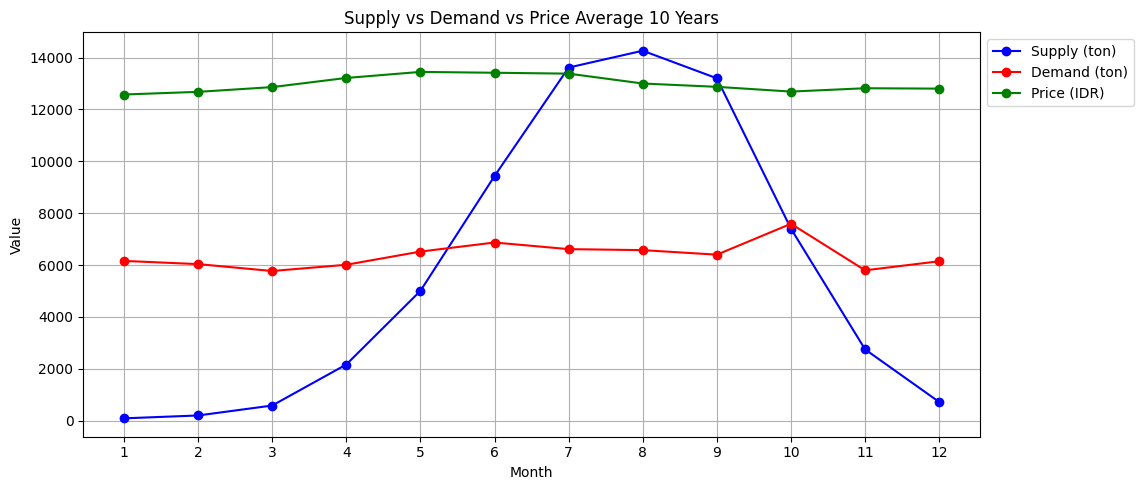

In [7]:
avg_supply_per_month = datas.groupby("Month")["Supply"].mean()
avg_demand_per_month = datas.groupby("Month")["Demand"].mean()
avg_price_per_month = datas.groupby("Month")["Price"].mean()
# Plot
plt.figure(figsize=(10, 5))
plt.plot(avg_supply_per_month.index, avg_supply_per_month.values, marker='o', linestyle='-', color='b', label='Supply (ton)')
plt.plot(avg_demand_per_month.index, avg_demand_per_month.values, marker='o', linestyle='-', color='r', label='Demand (ton)')
plt.plot(avg_price_per_month.index, avg_price_per_month.values, marker='o', linestyle='-', color='g', label='Price (IDR)')
plt.title("Supply vs Demand vs Price Average 10 Years")
plt.xlabel("Month")
plt.ylabel("Value")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('Supply vs Demand vs Price Average 10 Years.jpg', dpi=800)
plt.show()


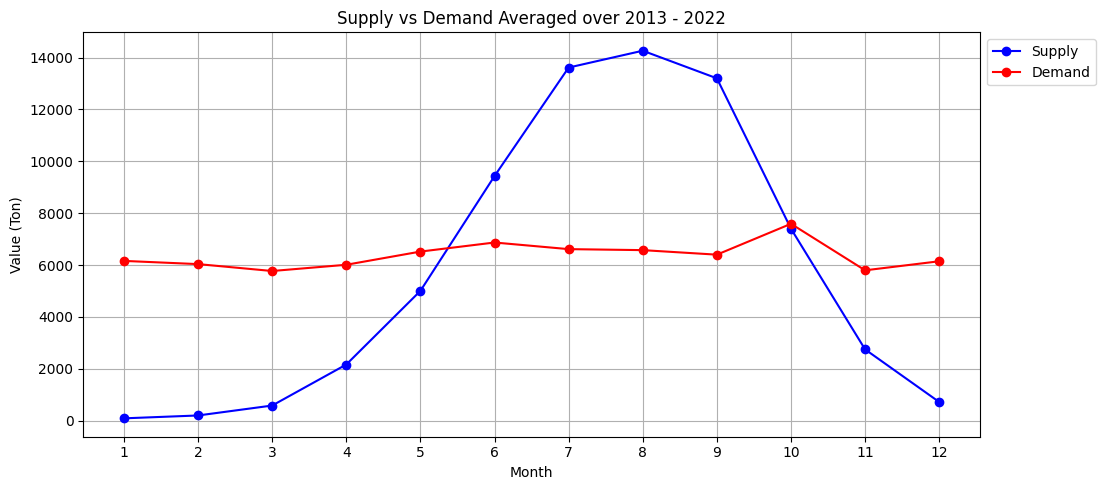

------------------------------------------------------------


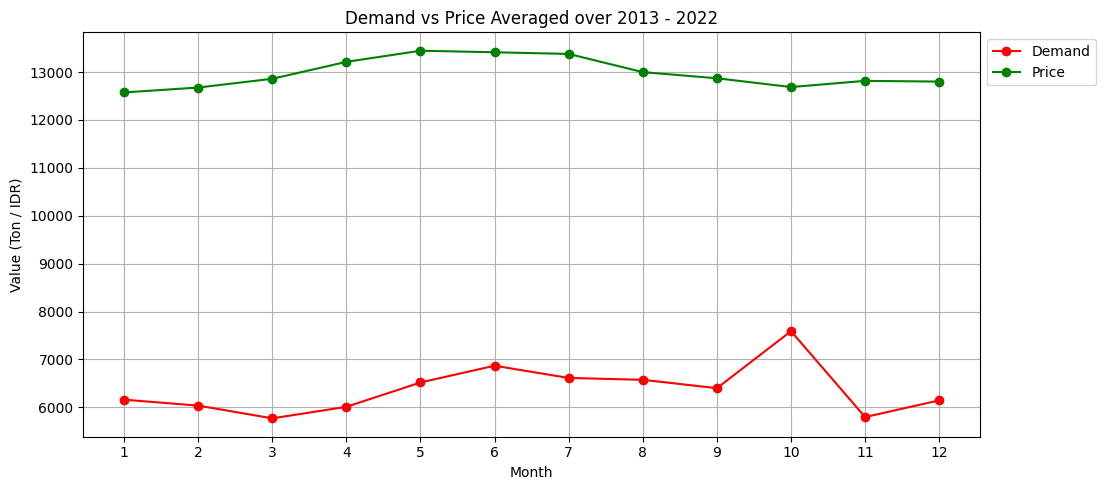

--


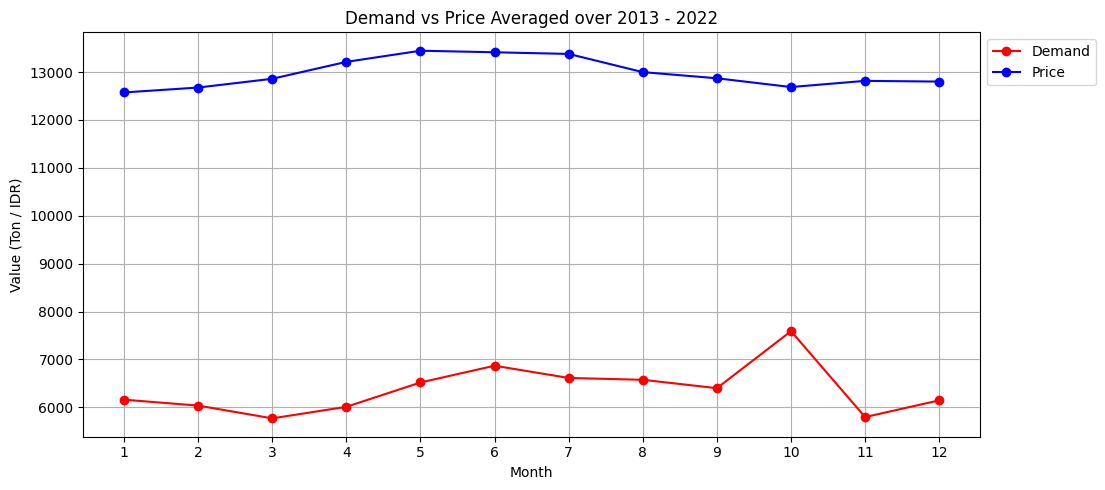

In [8]:
avg_supply_per_month = datas.groupby("Month")["Supply"].mean()
avg_demand_per_month = datas.groupby("Month")["Demand"].mean()
avg_price_per_month = datas.groupby("Month")["Price"].mean()
# Plot
plt.figure(figsize=(10, 5))
plt.plot(avg_supply_per_month.index, avg_supply_per_month.values, marker='o', linestyle='-', color='b', label='Supply')
plt.plot(avg_demand_per_month.index, avg_demand_per_month.values, marker='o', linestyle='-', color='r', label='Demand')
# plt.plot(avg_price_per_month.index, avg_price_per_month.values, marker='o', linestyle='-', color='g', label='Price (IDR)')
plt.title("Supply vs Demand Averaged over 2013 - 2022")
plt.xlabel("Month")
plt.ylabel("Value (Ton)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('Supply vs Demand Averaged over 2013 - 2022.jpg', dpi=800)
plt.show()


#---
print('--'*30)
plt.figure(figsize=(10, 5))
# plt.plot(avg_supply_per_month.index, avg_supply_per_month.values, marker='o', linestyle='-', color='b', label='Supply')
plt.plot(avg_demand_per_month.index, avg_demand_per_month.values, marker='o', linestyle='-', color='r', label='Demand')
plt.plot(avg_price_per_month.index, avg_price_per_month.values, marker='o', linestyle='-', color='g', label='Price')
plt.title("Demand vs Price Averaged over 2013 - 2022")
plt.xlabel("Month")
plt.ylabel("Value (Ton / IDR)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('Demand vs Price Averaged over 2013 - 2022.jpg', dpi=800)
plt.show()

print('--')
plt.figure(figsize=(10, 5))
# plt.plot(avg_supply_per_month.index, avg_supply_per_month.values, marker='o', linestyle='-', color='b', label='Supply')
plt.plot(avg_demand_per_month.index, avg_demand_per_month.values, marker='o', linestyle='-', color='r', label='Demand')
plt.plot(avg_price_per_month.index, avg_price_per_month.values, marker='o', linestyle='-', color='b', label='Price')
plt.title("Demand vs Price Averaged over 2013 - 2022")
plt.xlabel("Month")
plt.ylabel("Value (Ton / IDR)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('Demand vs Price Averaged over 2013 - 2022 (blue red).jpg', dpi=800)
plt.show()


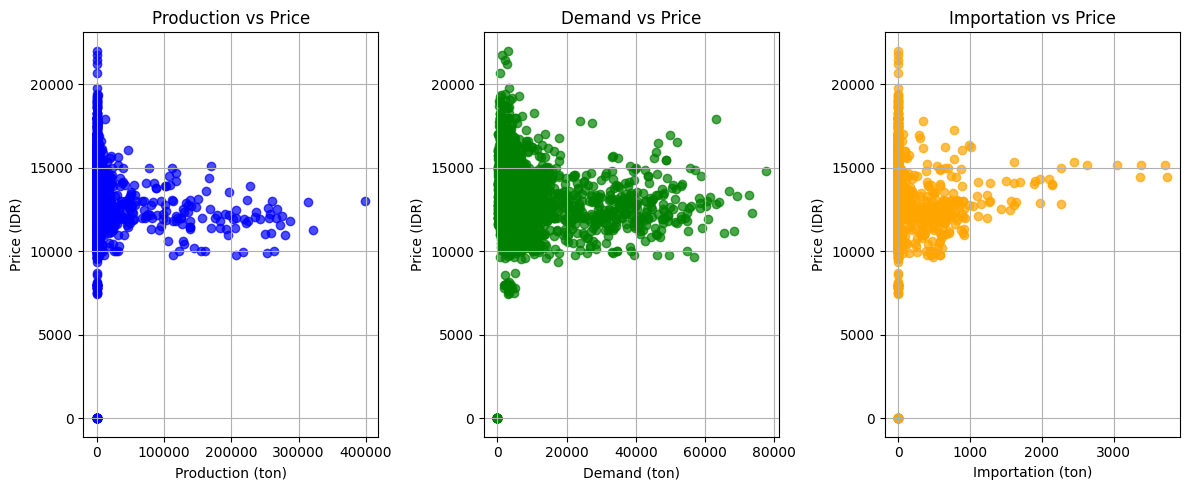

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Production (ton) vs Price (IDR)
plt.subplot(131)
plt.scatter(datas['Production'], datas['Price'], alpha=0.7, color='blue')
plt.xlabel("Production (ton)")
plt.ylabel("Price (IDR)")
plt.title("Production vs Price")
plt.grid(True)

# 2. Demand (ton) vs Price (IDR)
plt.subplot(132)
plt.scatter(datas['Demand'], datas['Price'], alpha=0.7, color='green')
plt.xlabel("Demand (ton)")
plt.ylabel("Price (IDR)")
plt.title("Demand vs Price")
plt.grid(True)

# 3. Importation (ton) vs Price (IDR)
plt.subplot(133)
plt.scatter(datas['Importation'], datas['Price'], alpha=0.7, color='orange')
plt.xlabel("Importation (ton)")
plt.ylabel("Price (IDR)")
plt.title("Importation vs Price")
plt.grid(True)

plt.tight_layout()
plt.savefig('scatter_plot_Prod_Impor_Demand_Price.jpg', dpi=800)
plt.show()


# DATA CLEANING

## 1) REMOVE IRRELEVANT FEATURES

In [10]:
data.columns

Index(['Unnamed: 0', 'Province', 'Year', 'Month', 'Production', 'Importation',
       'Demand', 'Supply', 'Price', 'Population', 'Religious Holiday',
       'residual', 'geometry', 'centroid', 'lon', 'lat', 'intercept',
       'Production_coef', 'Importation_coef', 'Demand_coef', 'Supply_coef',
       'Population_coef', 'Religious Holiday_coef', 'Production_pvalue',
       'Production_significant', 'Importation_pvalue',
       'Importation_significant', 'Demand_pvalue', 'Demand_significant',
       'Supply_pvalue', 'Supply_significant', 'Population_pvalue',
       'Population_significant', 'Religious Holiday_pvalue',
       'Religious Holiday_significant', 'Actual', 'Predicted', 'Residual'],
      dtype='object')

In [11]:
# # kolom_drop1 = ['Unnamed: 0', 'Unnamed: 0.1', 'No', 'geometry', 'centroid', 'lon', 'lat', 'Actual']
kolom_drop1 = ['Unnamed: 0', 'geometry', 'centroid', 'lon', 'lat', 'residual','Actual']
# kolom_drop1 = ['Unnamed: 0', 'Actual']
kolom_drop1

['Unnamed: 0', 'geometry', 'centroid', 'lon', 'lat', 'residual', 'Actual']

In [12]:
kolom_drop2 = data.columns[data.columns.str.endswith('significant')]
kolom_drop2 = kolom_drop2.tolist()
kolom_drop2

['Production_significant',
 'Importation_significant',
 'Demand_significant',
 'Supply_significant',
 'Population_significant',
 'Religious Holiday_significant']

In [13]:
kolom_drop = kolom_drop1 + kolom_drop2
kolom_drop

# kolom_drop = ['No']

['Unnamed: 0',
 'geometry',
 'centroid',
 'lon',
 'lat',
 'residual',
 'Actual',
 'Production_significant',
 'Importation_significant',
 'Demand_significant',
 'Supply_significant',
 'Population_significant',
 'Religious Holiday_significant']

In [14]:
data = data.drop(kolom_drop, axis=1)
data

,Province,Year,Month,Production,Importation,Demand,Supply,Price,Population,Religious Holiday,...,Population_coef,Religious Holiday_coef,Production_pvalue,Importation_pvalue,Demand_pvalue,Supply_pvalue,Population_pvalue,Religious Holiday_pvalue,Predicted,Residual
0,Aceh,2013,1,0.0,0.00,3262.0,0.00,12500.0,4811100,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13326.308616,-826.308616
1,Aceh,2013,1,0.0,16.02,3399.0,16.02,12000.0,4906800,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13371.300270,-1371.300270
2,Aceh,2013,1,0.0,0.00,2902.0,0.00,11000.0,5020000,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13295.987232,-2295.987232
3,Aceh,2013,1,0.0,0.00,2529.0,0.00,13000.0,5096200,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13281.710313,-281.710313
4,Aceh,2013,1,0.0,0.00,4706.0,0.00,14500.0,5189500,0,...,-0.646329,0.061372,0.984109,0.947903,0.697051,0.984258,0.018166,0.246776,13299.282435,1200.717565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,Yogyakarta,2017,11,0.0,0.00,2663.0,0.00,13239.0,3762200,0,...,0.201285,0.067044,0.014209,0.521890,0.374239,0.025180,0.013923,0.270268,12200.070293,1038.929707
4076,Yogyakarta,2017,12,0.0,0.00,4297.0,0.00,12424.0,3762200,1,...,0.201285,0.067044,0.014209,0.521890,0.374239,0.025180,0.013923,0.270268,12544.187168,-120.187168
4077,Yogyakarta,2017,12,0.0,0.00,2670.0,0.00,12500.0,3762200,1,...,0.201285,0.067044,0.014209,0.521890,0.374239,0.025180,0.013923,0.270268,12566.209965,-66.209965
4078,Yogyakarta,2017,12,0.0,0.00,3180.0,0.00,12500.0,3762200,1,...,0.201285,0.067044,0.014209,0.521890,0.374239,0.025180,0.013923,0.270268,12559.306691,-59.306691


In [15]:
data.columns.tolist()

['Province',
 'Year',
 'Month',
 'Production',
 'Importation',
 'Demand',
 'Supply',
 'Price',
 'Population',
 'Religious Holiday',
 'intercept',
 'Production_coef',
 'Importation_coef',
 'Demand_coef',
 'Supply_coef',
 'Population_coef',
 'Religious Holiday_coef',
 'Production_pvalue',
 'Importation_pvalue',
 'Demand_pvalue',
 'Supply_pvalue',
 'Population_pvalue',
 'Religious Holiday_pvalue',
 'Predicted',
 'Residual']

## 2) Nan Check

In [16]:
data.isna().sum()

Province                    0
Year                        0
Month                       0
Production                  0
Importation                 0
Demand                      0
Supply                      0
Price                       0
Population                  0
Religious Holiday           0
intercept                   0
Production_coef             0
Importation_coef            0
Demand_coef                 0
Supply_coef                 0
Population_coef             0
Religious Holiday_coef      0
Production_pvalue           0
Importation_pvalue          0
Demand_pvalue               0
Supply_pvalue               0
Population_pvalue           0
Religious Holiday_pvalue    0
Predicted                   0
Residual                    0
dtype: int64

In [17]:
# from sklearn.impute import KNNImputer

# cols_to_impute = ['Production', 'Demand', 'Supply', 'Price']
# # cols_to_impute


# imputer = KNNImputer(n_neighbors = 3)
# data[cols_to_impute] = imputer.fit_transform(data[cols_to_impute])
# data

# PROCESSING

## 1) Set Multi Index - PANEL 

In [18]:
data = data.set_index(['Province', 'Year', 'Month']).sort_index()
data 

Production  Importation  Demand  Supply    Price  \
Province   Year Month                                                     
Aceh       2013 1             0.0         0.00  3262.0    0.00  12500.0   
                1             0.0        16.02  3399.0   16.02  12000.0   
                1             0.0         0.00  2902.0    0.00  11000.0   
                1             0.0         0.00  2529.0    0.00  13000.0   
                1             0.0         0.00  4706.0    0.00  14500.0   
...                           ...          ...     ...     ...      ...   
Yogyakarta 2017 11            0.0         0.00  2663.0    0.00  13239.0   
                12            0.0         0.00  4297.0    0.00  12424.0   
                12            0.0         0.00  2670.0    0.00  12500.0   
                12            0.0         0.00  3180.0    0.00  12500.0   
                12            0.0         0.00  3724.0    0.00  13386.0   

                       Population  Religious Holiday  intercept  \
Province   Year Month                                             
Aceh       2013 1         4811100                  0   0.103006   
                1         4906800                  0   0.103006   
                1         5020000                  0   0.103006   
                1         5096200                  0   0.103006   
                1         5189500                  0   0.103006   
...                           ...                ...        ...   
Yogyakarta 2017 11        3762200                  0  -0.291752   
                12        3762200                  1  -0.291752   
                12        3762200                  1  -0.291752   
                12        3762200                  1  -0.291752   
                12        3762200                  1  -0.291752   

                       Production_coef  Importation_coef  ...  \
Province   Year Month                                     ...   
Aceh       2013 1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
...                                ...               ...  ...   
Yogyakarta 2017 11            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   

                       Population_coef  Religious Holiday_coef  \
Province   Year Month                                            
Aceh       2013 1            -0.646329                0.061372   
                1            -0.646329                0.061372   
                1            -0.646329                0.061372   
                1            -0.646329                0.061372   
                1            -0.646329                0.061372   
...                                ...                     ...   
Yogyakarta 2017 11            0.201285                0.067044   
                12            0.201285                0.067044   
                12            0.201285                0.067044   
                12            0.201285                0.067044   
                12            0.201285                0.067044   

                       Production_pvalue  Importation_pvalue  Demand_pvalue  \
Province   Year Month                                                         
Aceh       2013 1               0.984109            0.947903       0.697051   
                1               0.984109            0.947903       0.697051   
                1               0.984109            0.947903       0.697051   
                1               0.984109            0.947903       0.697051

In [19]:
data.columns

Index(['Production', 'Importation', 'Demand', 'Supply', 'Price', 'Population',
       'Religious Holiday', 'intercept', 'Production_coef', 'Importation_coef',
       'Demand_coef', 'Supply_coef', 'Population_coef',
       'Religious Holiday_coef', 'Production_pvalue', 'Importation_pvalue',
       'Demand_pvalue', 'Supply_pvalue', 'Population_pvalue',
       'Religious Holiday_pvalue', 'Predicted', 'Residual'],
      dtype='object')

## 2) SEPARATE DATA INTO FEATURES AND TARGET

In [20]:
# kolom_fitur = ['Production', 'Importation', 'Demand', 'Supply', 'Population',
#        'Religious Holiday', 'Economy Growth (%)', 'Inflation',
#        'Supply Positif', 'Supply Negatif', 'Demand Positif', 'Demand Negatif',
#        'Interaksi Positif', 'Interaksi Negatif', 'intercept',
#        'Production_coef', 'Importation_coef', 'Demand_coef', 'Supply_coef',
#        'Population_coef', 'Religious Holiday_coef', 'Economy Growth (%)_coef',
#        'Inflation_coef', 'Supply Negatif_coef', 'Supply Positif_coef',
#        'Demand Negatif_coef', 'Demand Positif_coef', 'Interaksi Negatif_coef',
#        'Interaksi Positif_coef', 'Production_pvalue', 'Importation_pvalue',
#        'Demand_pvalue', 'Supply_pvalue', 'Population_pvalue',
#        'Religious Holiday_pvalue', 'Economy Growth (%)_pvalue',
#        'Inflation_pvalue', 'Supply Negatif_pvalue', 'Supply Positif_pvalue',
#        'Demand Negatif_pvalue', 'Demand Positif_pvalue',
#        'Interaksi Negatif_pvalue', 'Interaksi Positif_pvalue', 'Predicted',
#        'Residual']

kolom_target = "Price"

kolom_fitur_coef = ['Production', 'Importation', 'Demand', 'Supply', 'Population',
       'Religious Holiday', 'intercept', 'Production_coef', 'Importation_coef',
       'Demand_coef', 'Supply_coef', 'Population_coef',
       'Religious Holiday_coef', 'Production_pvalue', 'Importation_pvalue',
       'Demand_pvalue', 'Supply_pvalue', 'Population_pvalue',
       'Religious Holiday_pvalue', 'Predicted', 'Residual']

kolom_fitur_tanpa_coef = ['Production', 'Importation', 'Demand', 'Supply', 'Population',
       'Religious Holiday', 'intercept', 'Production_pvalue', 'Importation_pvalue',
       'Demand_pvalue', 'Supply_pvalue', 'Population_pvalue',
       'Religious Holiday_pvalue', 'Predicted', 'Residual']

In [22]:
# data = data.sort_index(level=['Province','Year', 'Month'])
# data

In [23]:
# target_cols = [f"Price_t+{h}" for h in range(1, horizon + 1)]
# fitur_cols = data_shifted.columns.drop(target_cols)
# print("kolom sudah di tentukan...")

fitur_cols = kolom_fitur_coef
target_cols = kolom_target

In [24]:
# fitur_cols = [c for c in fitur_cols if c != 'residual_lr']
# fitur_cols

# DEFINE METRICS EVAL

In [25]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import pearsonr


def safe_mape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate_forecast_ts(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    # mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mape = mean_absolute_percentage_error(y_true, y_pred)

    cc, _ = pearsonr(y_true, y_pred)

    return r2, mse, rmse, mae, mape, cc

# DEFINE LSTM MODEL

In [26]:
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

def make_sequences(X, y, lookback):
    X_seq = []
    y_seq = []

    X = np.array(X)
    y = np.array(y)

    for i in range(len(X) - lookback + 1):
        X_seq.append(X[i:i+lookback])
        y_seq.append(y[i + lookback - 1])  # ⬅️ KUNCI

    return np.array(X_seq), np.array(y_seq)

# def make_sequences(X, y, lookback):
#     X_seq = []
#     y_seq = []

#     X = np.array(X)
#     y = np.array(y)

#     for i in range(len(X) - lookback):
#         X_seq.append(X[i:i+lookback])
#         y_seq.append(y[i+lookback])  # target di masa depan

#     return np.array(X_seq), np.array(y_seq)



# def lstm(X, y, Xv, yv, epoch, batchsize, callbacks):
#     model = Sequential()
#     model.add(Input(shape=(X.shape[1], X.shape[2])))
#     model.add(LSTM(64, activation='tanh', return_sequences=True))
#     model.add(Dropout(0.1))
#     model.add(LSTM(32, activation='tanh', return_sequences=False))
#     model.add(Dropout(0.1))

#     model.add(Dense(16, activation='relu'))
#     model.add(Dropout(0.1))
#     model.add(Dense(y.shape[1], activation='linear'))

#     optimizer=Adam(learning_rate=0.001)
#     model.compile(optimizer=optimizer, loss='mae')

#     history = model.fit(X, y,
#                        epochs=epoch,
#                        batch_size=batchsize,
#                        validation_data=(Xv, yv),
#                        verbose=0,
#                        callbacks=callbacks)
#     return model

def lstm(X, y, Xv, yv, epoch, batchsize, callbacks):
    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))
    model.add(LSTM(128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.3))

    # model.add(Dense(16, activation='relu'))
    # model.add(Dropout(0.1))
    model.add(Dense(y.shape[1]))

    optimizer=Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mse')

    history = model.fit(X, y,
                       epochs=epoch,
                       batch_size=batchsize,
                       validation_data=(Xv, yv),
                       verbose=0,
                       callbacks=callbacks)
    return model




# DEFINE CALLBACKS

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=0)
]

# FILTER WARNINGS

In [28]:
import warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# DEFINE META LEARNING MODELS :

## 1) MULTILAYER PERCEPTRON

In [29]:
# def mlp(X, y, Xv, yv, epoch, batchsize, callbacks, input_dim):
#     model = Sequential()

#     model.add(Dense(256, activation='relu', input_dim=input_dim))
#     model.add(Dense(128, activation='relu'))
#     model.add(Dense(64, activation='relu'))
#     model.add(Dense(16, activation='relu'))
#     model.add(Dense(8, activation='relu'))
#     model.add(Dense(y.shape[1], activation='linear'))

#     optimizer=AdamW(learning_rate=0.001)
#     model.compile(optimizer=optimizer, loss='mae')

#     history = model.fit(X, y,
#                        epochs=epoch,
#                        batch_size=batchsize,
#                        validation_data=(Xv, yv),
#                        verbose=1,
#                        callbacks=callbacks)
#     return model

def mlp(X, y, Xv, yv, epoch, batchsize, callbacks, input_dim):
    model = Sequential()
    model.add(Dense(16, activation='relu', input_dim=input_dim))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(y.shape[1]))

    optimizer=Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse')

    history = model.fit(X, y,
                       epochs=epoch,
                       batch_size=batchsize,
                       validation_data=(Xv, yv),
                       verbose=0,
                       callbacks=callbacks)
    return model

## 2) TEMPORAL CONVOLUTIONAL NETWORK (TCN)

In [ ]:
!pip install keras-tcn

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tcn import TCN


def tcn(meta_timesteps, n_features, n_outputs):
    model = Sequential()
    model.add(
        TCN(
            input_shape=(meta_timesteps, n_features),
            nb_filters=64,
            kernel_size=3,
            dilations=[1, 2, 4, 8],
            dropout_rate=0.2,
            return_sequences=False
        )
    )
    model.add(Dense(16, activation="relu"))
    model.add(Dense(n_outputs, activation="linear"))
    model.compile(
        optimizer=AdamW(learning_rate=0.001),
        loss="mae"
    )
    return model

# TRAINING :

# 1) USING DEFAULT TRAINING (80:10:10)

## -----------------------------------

## 1.1) WITH GWPR COEFFICIENTS

In [32]:
data

Production  Importation  Demand  Supply    Price  \
Province   Year Month                                                     
Aceh       2013 1             0.0         0.00  3262.0    0.00  12500.0   
                1             0.0        16.02  3399.0   16.02  12000.0   
                1             0.0         0.00  2902.0    0.00  11000.0   
                1             0.0         0.00  2529.0    0.00  13000.0   
                1             0.0         0.00  4706.0    0.00  14500.0   
...                           ...          ...     ...     ...      ...   
Yogyakarta 2017 11            0.0         0.00  2663.0    0.00  13239.0   
                12            0.0         0.00  4297.0    0.00  12424.0   
                12            0.0         0.00  2670.0    0.00  12500.0   
                12            0.0         0.00  3180.0    0.00  12500.0   
                12            0.0         0.00  3724.0    0.00  13386.0   

                       Population  Religious Holiday  intercept  \
Province   Year Month                                             
Aceh       2013 1         4811100                  0   0.103006   
                1         4906800                  0   0.103006   
                1         5020000                  0   0.103006   
                1         5096200                  0   0.103006   
                1         5189500                  0   0.103006   
...                           ...                ...        ...   
Yogyakarta 2017 11        3762200                  0  -0.291752   
                12        3762200                  1  -0.291752   
                12        3762200                  1  -0.291752   
                12        3762200                  1  -0.291752   
                12        3762200                  1  -0.291752   

                       Production_coef  Importation_coef  ...  \
Province   Year Month                                     ...   
Aceh       2013 1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
                1           -11.279521          0.291729  ...   
...                                ...               ...  ...   
Yogyakarta 2017 11            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   
                12            0.162268          0.128715  ...   

                       Population_coef  Religious Holiday_coef  \
Province   Year Month                                            
Aceh       2013 1            -0.646329                0.061372   
                1            -0.646329                0.061372   
                1            -0.646329                0.061372   
                1            -0.646329                0.061372   
                1            -0.646329                0.061372   
...                                ...                     ...   
Yogyakarta 2017 11            0.201285                0.067044   
                12            0.201285                0.067044   
                12            0.201285                0.067044   
                12            0.201285                0.067044   
                12            0.201285                0.067044   

                       Production_pvalue  Importation_pvalue  Demand_pvalue  \
Province   Year Month                                                         
Aceh       2013 1               0.984109            0.947903       0.697051   
                1               0.984109            0.947903       0.697051   
                1               0.984109            0.947903       0.697051   
                1               0.984109            0.947903       0.697051

## 1.1.1  META MLP : 3 TOP HYBRID (LSTM-ARIMA-SARIMA)

In [33]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

######################################### PARAMETERS #########################################
lookback_lstm = 1

order = (2, 1, 2)
seasonal_order = (1,0,1,12)

epoch = 100
batchsize = 32

epochmlp = 50
batchsizemlp = 32

result = []
result_sarima = []
result_arima = []
result_lstm = []

pred_meta1 = []
pred_meta2 = []
pred_meta3 = []

###########################################################################################################################

X = data[fitur_cols]
y = data[target_cols]

# ==============================
# 1. BUAT TIME KEY
# ==============================
time_key = pd.Series(
    data.index.get_level_values('Year') * 100 +
    data.index.get_level_values('Month'),
    index=data.index
)

# ==============================
# 2. TRAIN / VAL / TEST SPLIT 80:10:10 per Province
# ==============================
train_index = []
val_index   = []
test_index  = []

provinces = X.index.get_level_values('Province').unique()

for prov in provinces:
    idx_prov = X.index[X.index.get_level_values('Province') == prov]
    idx_sorted = idx_prov.sort_values()
    
    n = len(idx_sorted)
    n_train = int(n * 0.8)
    n_val   = int(n * 0.1)
    n_test  = n - n_train - n_val
    
    if n_train > 0:
        train_index.extend(idx_sorted[:n_train])
    if n_val > 0:
        val_index.extend(idx_sorted[n_train:n_train+n_val])
    if n_test > 0:
        test_index.extend(idx_sorted[n_train+n_val:])

train_mask = X.index.isin(train_index)
val_mask   = X.index.isin(val_index)
test_mask  = X.index.isin(test_index)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

y_train = np.array(y_train).reshape(-1,1)
y_val   = np.array(y_val).reshape(-1,1)
y_test  = np.array(y_test).reshape(-1,1)

# ==============================
# 3. SCALING
# ==============================
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

X_val_scaled = scaler_x.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_x.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=fitur_cols)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=fitur_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=fitur_cols)

# ==============================
# 4. SARIMA — TRAINING & EVALUASI
# ==============================

y_train_sarima = y_train_scaled.ravel()
y_val_sarima   = y_val_scaled.ravel()
y_test_sarima  = y_test_scaled.ravel()

model_sarima = sm.tsa.SARIMAX(
    endog=y_train_sarima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = model_sarima.fit(disp=False)

sarima_pred_train = sarima_fit.predict(start=0, end=len(y_train_sarima)-1).reshape(-1,1)
sarima_pred_val   = sarima_fit.get_forecast(steps=len(y_val_sarima)).predicted_mean.reshape(-1,1)

start_time = time.time()
sarima_pred_test  = sarima_fit.get_forecast(steps=len(y_test_sarima)).predicted_mean.reshape(-1,1)
time_sarima = time.time() - start_time

sarima_pred_train = sarima_pred_train[lookback_lstm-1:]
sarima_pred_val   = sarima_pred_val[lookback_lstm-1:]
sarima_pred_test  = sarima_pred_test[lookback_lstm-1:]

y_train_eff = y_train_sarima[lookback_lstm-1:].reshape(-1,1)
y_val_eff   = y_val_sarima[lookback_lstm-1:].reshape(-1,1)
y_test_eff  = y_test_sarima[lookback_lstm-1:].reshape(-1,1)

sarima_pred_test_orig  = scaler_y.inverse_transform(sarima_pred_test)


# EVALUASI SARIMA
r2_sarima, mse_sarima, rmse_sarima, mae_sarima, mape_sarima, cc_sarima = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_eff), sarima_pred_test_orig
)

print("=== EVALUASI SARIMA ===")
print("R2    :", r2_sarima)
print("MSE   :", mse_sarima)
print("RMSE  :", rmse_sarima)
print("MAE   :", mae_sarima)
print("MAPE  :", mape_sarima)
print("CC    :", cc_sarima)
print("-----------------------")

result_sarima.append({
    'R2_sarima': r2_sarima, 'MSE_sarima': mse_sarima,
    'RMSE_sarima': rmse_sarima, 'MAE_sarima': mae_sarima,
    'MAPE_sarima': mape_sarima, 'CC_sarima': cc_sarima
})

# ==============================
# 5. ARIMA — TRAINING & EVALUASI
# ==============================

y_train_arima = y_train_scaled.ravel()
y_val_arima   = y_val_scaled.ravel()
y_test_arima  = y_test_scaled.ravel()

model_arima = sm.tsa.ARIMA(
    endog=y_train_arima,
    order=order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
arima_fit = model_arima.fit()

arima_pred_train  = arima_fit.get_forecast(steps=len(y_train_arima)).predicted_mean.reshape(-1,1)
arima_pred_val  = arima_fit.get_forecast(steps=len(y_val_arima)).predicted_mean.reshape(-1,1)

start_time = time.time()
arima_pred_test  = arima_fit.get_forecast(steps=len(y_test_arima)).predicted_mean.reshape(-1,1)
time_arima = time.time() - start_time

arima_pred_train = arima_pred_train[lookback_lstm-1:]
arima_pred_val   = arima_pred_val[lookback_lstm-1:]
arima_pred_test  = arima_pred_test[lookback_lstm-1:]

y_train_eff = y_train_arima[lookback_lstm-1:].reshape(-1,1)
y_val_eff   = y_val_arima[lookback_lstm-1:].reshape(-1,1)
y_test_eff  = y_test_arima[lookback_lstm-1:].reshape(-1,1)

arima_pred_test_orig  = scaler_y.inverse_transform(arima_pred_test)


# EVALUASI ARIMA
r2_arima, mse_arima, rmse_arima, mae_arima, mape_arima, cc_arima = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_eff), arima_pred_test_orig
)

print("=== EVALUASI ARIMA ===")
print("R2    :", r2_arima)
print("MSE   :", mse_arima)
print("RMSE  :", rmse_arima)
print("MAE   :", mae_arima)
print("MAPE  :", mape_arima)
print("CC    :", cc_arima)
print("-----------------------")

result_arima.append({
    'R2_arima': r2_arima, 'MSE_arima': mse_arima,
    'RMSE_arima': rmse_arima, 'MAE_arima': mae_arima,
    'MAPE_arima': mape_arima, 'CC_arima': cc_arima
})

# ==============================
# 6. LSTM — TRAINING & EVALUASI
# ==============================

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, lookback_lstm)
X_val_seq, y_val_seq     = make_sequences(X_val_scaled, y_val_scaled, lookback_lstm)
X_test_seq, y_test_seq   = make_sequences(X_test_scaled, y_test_scaled, lookback_lstm)

model_lstm = lstm(X_train_seq, y_train_seq, X_val_seq, y_val_seq, epoch=epoch, batchsize=batchsize, callbacks=callbacks)
y_pred_train_lstm  = model_lstm.predict(X_train_seq)
y_pred_val_lstm  = model_lstm.predict(X_val_seq)
start_time = time.time()
y_pred_test_lstm  = model_lstm.predict(X_test_seq)
y_pred_test_lstm_orig  = scaler_y.inverse_transform(y_pred_test_lstm)
time_lstm = time.time() - start_time

# EVALUASI LSTM
r2_lstm, mse_lstm, rmse_lstm, mae_lstm, mape_lstm, cc_lstm = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_seq), y_pred_test_lstm_orig
)

print("=== EVALUASI LSTM ===")
print("R2    :", r2_lstm)
print("MSE   :", mse_lstm)
print("RMSE  :", rmse_lstm)
print("MAE   :", mae_lstm)
print("MAPE  :", mape_lstm)
print("CC    :", cc_lstm)
print("-----------------------")

result_lstm.append({
    'R2_lstm': r2_lstm, 'MSE_lstm': mse_lstm,
    'RMSE_lstm': rmse_lstm, 'MAE_lstm': mae_lstm,
    'MAPE_lstm': mape_lstm, 'CC_lstm': cc_lstm
})

print(y_pred_train_lstm.shape)
print(arima_pred_train.shape)
# # ==============================
# # 7. META LEARNING - MLP
# # ==============================
X_meta_train_1 = np.hstack((arima_pred_train, y_pred_train_lstm))
X_meta_val_1   = np.hstack((arima_pred_val,   y_pred_val_lstm))
X_meta_test_1  = np.hstack((arima_pred_test,  y_pred_test_lstm))

X_meta_train_2 = np.hstack((sarima_pred_train, y_pred_train_lstm))
X_meta_val_2   = np.hstack((sarima_pred_val,   y_pred_val_lstm))
X_meta_test_2  = np.hstack((sarima_pred_test,  y_pred_test_lstm))

X_meta_train_3 = np.hstack((arima_pred_train, sarima_pred_train, y_pred_train_lstm))
X_meta_val_3   = np.hstack((arima_pred_val,   sarima_pred_val,   y_pred_val_lstm))
X_meta_test_3  = np.hstack((arima_pred_test,  sarima_pred_test,  y_pred_test_lstm))

y_meta_train = y_train_eff
y_meta_val   = y_val_eff
y_meta_test  = y_test_eff

# # ==============================
# # 7. META LEARNING - MLP (training & testing)
# # ==============================
meta_variants = {
    "LSTM_ARIMA":  (X_meta_train_1, X_meta_val_1, X_meta_test_1),
    "LSTM_SARIMA": (X_meta_train_2, X_meta_val_2, X_meta_test_2),
    "LSTM_ARIMA_SARIMA": (X_meta_train_3, X_meta_val_3, X_meta_test_3)
}

time_meta = {}
total_meta_time = 0

for name, (Xm_train, Xm_val, Xm_test) in meta_variants.items():
    
    # TRAIN META MLP
    meta_mlp = mlp(
        Xm_train, y_meta_train,    # training
        Xm_val, y_meta_val,        # validation
        epoch=epochmlp,
        batchsize=batchsizemlp,
        callbacks=callbacks,
        input_dim=Xm_train.shape[1]
    )
    
    # PREDIKSI TEST META & HITUNG TIME
    start_time = time.time()
    y_pred_meta_scaled = meta_mlp.predict(Xm_test)  # masih scaled
    time_taken = time.time() - start_time
    time_meta[name] = time_taken
    total_meta_time += time_taken

    # INVERSE SCALING HANYA SETELAH PREDIKSI
    y_true = scaler_y.inverse_transform(y_meta_test.reshape(-1,1))
    y_pred = scaler_y.inverse_transform(y_pred_meta_scaled.reshape(-1,1))

    # EVALUASI
    r2, mse, rmse, mae, mape, cc = evaluate_forecast_ts(y_true, y_pred)

    print(f"=== EVALUASI META {name} ===")
    print("R2    :", r2)
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("MAE   :", mae)
    print("MAPE  :", mape)
    print("CC    :", cc)
    print("-----------------------")

    # SIMPAN HASIL
    result.append({
        'model': name,
        'R2_meta': r2,
        'MSE_meta': mse,
        'RMSE_meta': rmse,
        'MAE_meta': mae,
        'MAPE_meta': mape,
        'CC_meta': cc
    })

    # =========================
    # SIMPAN PREDIKSI PER META
    # =========================
    
    df_pred_fold = pd.DataFrame({
        'actual': y_true.ravel(),
        'prediction': y_pred.ravel()
    })
    
    if name == "LSTM_ARIMA":
        pred_meta1.append(df_pred_fold)
    
    elif name == "LSTM_SARIMA":
        pred_meta2.append(df_pred_fold)
    
    elif name == "LSTM_ARIMA_SARIMA":
        pred_meta3.append(df_pred_fold)


=== EVALUASI SARIMA ===
R2    : -0.1434753334605674
MSE   : 2074785.4147809409
RMSE  : 1440.4115435461285
MAE   : 1135.2912732161892
MAPE  : 0.09292092896407723
CC    : -0.03702669913469959
-----------------------
=== EVALUASI ARIMA ===
R2    : -0.1429082134833839
MSE   : 2073756.400666985
RMSE  : 1440.0543047631868
MAE   : 1134.9755319028602
MAPE  : 0.09289006751926565
CC    : -0.034766997601552926
-----------------------


I0000 00:00:1771317655.831992      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
2026-02-17 08:40:57.333304: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1771317660.488370     137 cuda_dnn.cc:529] Loaded

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
=== EVALUASI LSTM ===
R2    : 0.946858328972813
MSE   : 96423.21153584962
RMSE  : 310.52087133693544
MAE   : 233.73730938251202
MAPE  : 0.01832421838356777
CC    : 0.9750838873051905
-----------------------
(3368, 1)
(3368, 1)
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


2026-02-17 08:42:24.864405: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


=== EVALUASI META LSTM_ARIMA ===
R2    : 0.9452836611927212
MSE   : 99280.37657269607
RMSE  : 315.0878870612072
MAE   : 228.02807147686298
MAPE  : 0.01790408501843311
CC    : 0.9750348673466405
-----------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


2026-02-17 08:42:46.344935: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


=== EVALUASI META LSTM_SARIMA ===
R2    : 0.9434972738640423
MSE   : 102521.69736575239
RMSE  : 320.1900956709192
MAE   : 231.33144437349756
MAPE  : 0.017930648997584953
CC    : 0.9752665181326419
-----------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
=== EVALUASI META LSTM_ARIMA_SARIMA ===
R2    : 0.9443459591765588
MSE   : 100981.79540492976
RMSE  : 317.7763292080292
MAE   : 229.47136120918464
MAPE  : 0.01781777562530195
CC    : 0.9751576125452199
-----------------------


2026-02-17 08:43:03.565835: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [34]:
df_meta1_tanpa_fold = pd.concat(pred_meta1, ignore_index=True)
df_meta2_tanpa_fold = pd.concat(pred_meta2, ignore_index=True)
df_meta3_tanpa_fold = pd.concat(pred_meta3, ignore_index=True)

df_meta1_tanpa_fold.to_excel('pred_vs_aktual_LSTM_ARIMA_TANPA_FOLD.xlsx')
df_meta2_tanpa_fold.to_excel('pred_vs_aktual_LSTM_SARIMA_TANPA_FOLD.xlsx')
df_meta3_tanpa_fold.to_excel('pred_vs_aktual_LSTM_ARIMA_SARIMA_TANPA_FOLD.xlsx')

# ==============================
# 8. TOTAL TIME & SUMMARY DF
# ==============================
total_time = time_arima + time_sarima + time_lstm + total_meta_time

df_time_summary = pd.DataFrame([{
    "TIME_ARIMA": time_arima,
    "TIME_SARIMA": time_sarima,
    "TIME_LSTM": time_lstm,
    "TIME_LSTM_ARIMA": time_meta["LSTM_ARIMA"],
    "TIME_LSTM_SARIMA": time_meta["LSTM_SARIMA"],
    "TIME_LSTM_ARIMA_SARIMA": time_meta["LSTM_ARIMA_SARIMA"],
    "TIME_TOTAL": total_time
}])

df_time_summary.to_excel('time_inference_MLP-LSTM-ARIMA-SARIMA.xlsx')

df_result = pd.DataFrame(result)
df_result_sarima_tanpa_fold = pd.DataFrame(result_sarima)
df_result_arima_tanpa_fold = pd.DataFrame(result_arima)
df_result_lstm_tanpa_fold = pd.DataFrame(result_lstm)

df_result_sarima_tanpa_fold.to_excel('result_SARIMA_TANPA_FOLD.xlsx')
df_result_arima_tanpa_fold.to_excel('result_ARIMA_TANPA_FOLD.xlsx')
df_result_lstm_tanpa_fold.to_excel('result_LSTM_TANPA_FOLD.xlsx')

# Pisahkan berdasarkan model
df_result_lstm_arima_tanpa_fold = df_result[df_result["model"] == "LSTM_ARIMA"].reset_index(drop=True)
df_result_lstm_sarima_tanpa_fold = df_result[df_result["model"] == "LSTM_SARIMA"].reset_index(drop=True)
df_result_lstm_arima_sarima_tanpa_fold = df_result[df_result["model"] == "LSTM_ARIMA_SARIMA"].reset_index(drop=True)

df_result_lstm_arima_tanpa_fold.columns = ['model', 'r2','mse','rmse','mae','mape','cc']
df_result_lstm_sarima_tanpa_fold.columns = ['model', 'r2','mse','rmse','mae','mape','cc']
df_result_lstm_arima_sarima_tanpa_fold.columns = ['model', 'r2','mse','rmse','mae','mape','cc']

df_result_lstm_arima_tanpa_fold.to_excel('result_LSTM-ARIMA-MLP (TANPA FOLD).xlsx')
df_result_lstm_sarima_tanpa_fold.to_excel('result_LSTM-SARIMA-MLP (TANPA FOLD).xlsx')
df_result_lstm_arima_sarima_tanpa_fold.to_excel('result_LSTM-ARIMA-SARIMA-MLP (TANPA FOLD).xlsx')

## 1.1.2  META TCN : 3 TOP HYBRID (LSTM-ARIMA-SARIMA)

In [35]:
def to_tcn_input(X):
    return X.reshape((X.shape[0], 1, X.shape[1]))


In [36]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

######################################### PARAMETERS #########################################
lookback_lstm = 1

order = (2, 1, 2)
seasonal_order = (1,0,1,12)

epoch = 100
batchsize = 32

epochmlp = 50
batchsizemlp = 32

result = []
result_sarima = []
result_arima = []
result_lstm = []

pred_meta1 = []
pred_meta2 = []
pred_meta3 = []

###########################################################################################################################

X = data[fitur_cols]
y = data[target_cols]

# ==============================
# 1. BUAT TIME KEY
# ==============================
time_key = pd.Series(
    data.index.get_level_values('Year') * 100 +
    data.index.get_level_values('Month'),
    index=data.index
)

# ==============================
# 2. TRAIN / VAL / TEST SPLIT 80:10:10 per Province
# ==============================
train_index = []
val_index   = []
test_index  = []

provinces = X.index.get_level_values('Province').unique()

for prov in provinces:
    idx_prov = X.index[X.index.get_level_values('Province') == prov]
    idx_sorted = idx_prov.sort_values()
    
    n = len(idx_sorted)
    n_train = int(n * 0.8)
    n_val   = int(n * 0.1)
    n_test  = n - n_train - n_val
    
    if n_train > 0:
        train_index.extend(idx_sorted[:n_train])
    if n_val > 0:
        val_index.extend(idx_sorted[n_train:n_train+n_val])
    if n_test > 0:
        test_index.extend(idx_sorted[n_train+n_val:])

train_mask = X.index.isin(train_index)
val_mask   = X.index.isin(val_index)
test_mask  = X.index.isin(test_index)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

y_train = np.array(y_train).reshape(-1,1)
y_val   = np.array(y_val).reshape(-1,1)
y_test  = np.array(y_test).reshape(-1,1)

# ==============================
# 3. SCALING
# ==============================
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

X_val_scaled = scaler_x.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_x.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=fitur_cols)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=fitur_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=fitur_cols)

# ==============================
# 4. SARIMA — TRAINING & EVALUASI
# ==============================

y_train_sarima = y_train_scaled.ravel()
y_val_sarima   = y_val_scaled.ravel()
y_test_sarima  = y_test_scaled.ravel()

model_sarima = sm.tsa.SARIMAX(
    endog=y_train_sarima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = model_sarima.fit(disp=False)

sarima_pred_train = sarima_fit.predict(start=0, end=len(y_train_sarima)-1).reshape(-1,1)
sarima_pred_val   = sarima_fit.get_forecast(steps=len(y_val_sarima)).predicted_mean.reshape(-1,1)

start_time = time.time()
sarima_pred_test  = sarima_fit.get_forecast(steps=len(y_test_sarima)).predicted_mean.reshape(-1,1)
time_sarima = time.time() - start_time

sarima_pred_train = sarima_pred_train[lookback_lstm-1:]
sarima_pred_val   = sarima_pred_val[lookback_lstm-1:]
sarima_pred_test  = sarima_pred_test[lookback_lstm-1:]

y_train_eff = y_train_sarima[lookback_lstm-1:].reshape(-1,1)
y_val_eff   = y_val_sarima[lookback_lstm-1:].reshape(-1,1)
y_test_eff  = y_test_sarima[lookback_lstm-1:].reshape(-1,1)

sarima_pred_test_orig  = scaler_y.inverse_transform(sarima_pred_test)


# EVALUASI SARIMA
r2_sarima, mse_sarima, rmse_sarima, mae_sarima, mape_sarima, cc_sarima = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_eff), sarima_pred_test_orig
)

print("=== EVALUASI SARIMA ===")
print("R2    :", r2_sarima)
print("MSE   :", mse_sarima)
print("RMSE  :", rmse_sarima)
print("MAE   :", mae_sarima)
print("MAPE  :", mape_sarima)
print("CC    :", cc_sarima)
print("-----------------------")

result_sarima.append({
    'R2_sarima': r2_sarima, 'MSE_sarima': mse_sarima,
    'RMSE_sarima': rmse_sarima, 'MAE_sarima': mae_sarima,
    'MAPE_sarima': mape_sarima, 'CC_sarima': cc_sarima
})

# ==============================
# 5. ARIMA — TRAINING & EVALUASI
# ==============================

y_train_arima = y_train_scaled.ravel()
y_val_arima   = y_val_scaled.ravel()
y_test_arima  = y_test_scaled.ravel()

model_arima = sm.tsa.ARIMA(
    endog=y_train_arima,
    order=order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
arima_fit = model_arima.fit()

arima_pred_train  = arima_fit.get_forecast(steps=len(y_train_arima)).predicted_mean.reshape(-1,1)
arima_pred_val  = arima_fit.get_forecast(steps=len(y_val_arima)).predicted_mean.reshape(-1,1)

start_time = time.time()
arima_pred_test  = arima_fit.get_forecast(steps=len(y_test_arima)).predicted_mean.reshape(-1,1)
time_arima = time.time() - start_time

arima_pred_train = arima_pred_train[lookback_lstm-1:]
arima_pred_val   = arima_pred_val[lookback_lstm-1:]
arima_pred_test  = arima_pred_test[lookback_lstm-1:]

y_train_eff = y_train_arima[lookback_lstm-1:].reshape(-1,1)
y_val_eff   = y_val_arima[lookback_lstm-1:].reshape(-1,1)
y_test_eff  = y_test_arima[lookback_lstm-1:].reshape(-1,1)

arima_pred_test_orig  = scaler_y.inverse_transform(arima_pred_test)


# EVALUASI ARIMA
r2_arima, mse_arima, rmse_arima, mae_arima, mape_arima, cc_arima = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_eff), arima_pred_test_orig
)

print("=== EVALUASI ARIMA ===")
print("R2    :", r2_arima)
print("MSE   :", mse_arima)
print("RMSE  :", rmse_arima)
print("MAE   :", mae_arima)
print("MAPE  :", mape_arima)
print("CC    :", cc_arima)
print("-----------------------")

result_arima.append({
    'R2_arima': r2_arima, 'MSE_arima': mse_arima,
    'RMSE_arima': rmse_arima, 'MAE_arima': mae_arima,
    'MAPE_arima': mape_arima, 'CC_arima': cc_arima
})

# ==============================
# 6. LSTM — TRAINING & EVALUASI
# ==============================

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, lookback_lstm)
X_val_seq, y_val_seq     = make_sequences(X_val_scaled, y_val_scaled, lookback_lstm)
X_test_seq, y_test_seq   = make_sequences(X_test_scaled, y_test_scaled, lookback_lstm)

model_lstm = lstm(X_train_seq, y_train_seq, X_val_seq, y_val_seq, epoch=epoch, batchsize=batchsize, callbacks=callbacks)
y_pred_train_lstm  = model_lstm.predict(X_train_seq)
y_pred_val_lstm  = model_lstm.predict(X_val_seq)
start_time = time.time()
y_pred_test_lstm  = model_lstm.predict(X_test_seq)
y_pred_test_lstm_orig  = scaler_y.inverse_transform(y_pred_test_lstm)
time_lstm = time.time() - start_time

# EVALUASI LSTM
r2_lstm, mse_lstm, rmse_lstm, mae_lstm, mape_lstm, cc_lstm = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_seq), y_pred_test_lstm_orig
)

print("=== EVALUASI LSTM ===")
print("R2    :", r2_lstm)
print("MSE   :", mse_lstm)
print("RMSE  :", rmse_lstm)
print("MAE   :", mae_lstm)
print("MAPE  :", mape_lstm)
print("CC    :", cc_lstm)
print("-----------------------")

result_lstm.append({
    'R2_lstm': r2_lstm, 'MSE_lstm': mse_lstm,
    'RMSE_lstm': rmse_lstm, 'MAE_lstm': mae_lstm,
    'MAPE_lstm': mape_lstm, 'CC_lstm': cc_lstm
})

print(y_pred_train_lstm.shape)
print(arima_pred_train.shape)


# # ==============================
# # 7. META LEARNING - TCN
# # ==============================
X_meta_train_1 = np.hstack((arima_pred_train, y_pred_train_lstm))
X_meta_val_1   = np.hstack((arima_pred_val,   y_pred_val_lstm))
X_meta_test_1  = np.hstack((arima_pred_test,  y_pred_test_lstm))

X_meta_train_2 = np.hstack((sarima_pred_train, y_pred_train_lstm))
X_meta_val_2   = np.hstack((sarima_pred_val,   y_pred_val_lstm))
X_meta_test_2  = np.hstack((sarima_pred_test,  y_pred_test_lstm))

X_meta_train_3 = np.hstack((arima_pred_train, sarima_pred_train, y_pred_train_lstm))
X_meta_val_3   = np.hstack((arima_pred_val,   sarima_pred_val,   y_pred_val_lstm))
X_meta_test_3  = np.hstack((arima_pred_test,  sarima_pred_test,  y_pred_test_lstm))

y_meta_train = y_train_eff
y_meta_val   = y_val_eff
y_meta_test  = y_test_eff

# # ==============================
# # 7. META LEARNING - TCN (training & testing)
# # ==============================
meta_variants = {
    "LSTM_ARIMA":  (X_meta_train_1, X_meta_val_1, X_meta_test_1),
    "LSTM_SARIMA": (X_meta_train_2, X_meta_val_2, X_meta_test_2),
    "LSTM_ARIMA_SARIMA": (X_meta_train_3, X_meta_val_3, X_meta_test_3)
}

time_meta = {}
total_meta_time = 0

for name, (Xm_train, Xm_val, Xm_test) in meta_variants.items():
    
    # ======================
    # RESHAPE UNTUK TCN
    # ======================
    Xm_train_tcn = to_tcn_input(Xm_train)
    Xm_val_tcn   = to_tcn_input(Xm_val)
    Xm_test_tcn  = to_tcn_input(Xm_test)

    # ======================
    # BUILD MODEL TCN
    # ======================
    meta_tcn = tcn(
        meta_timesteps=1,
        n_features=Xm_train.shape[1],
        n_outputs=1
    )

    # ======================
    # TRAIN
    # ======================
    meta_tcn.fit(
        Xm_train_tcn, y_meta_train,
        validation_data=(Xm_val_tcn, y_meta_val),
        epochs=epochmlp,
        batch_size=batchsizemlp,
        callbacks=callbacks,
        verbose=1
    )

    # ======================
    # PREDICT TEST
    # ======================
    start_time = time.time()
    y_pred_meta_scaled = meta_tcn.predict(Xm_test_tcn)
    time_taken = time.time() - start_time
    time_meta[name] = time_taken
    total_meta_time += time_taken

    # ======================
    # INVERSE SCALE
    # ======================
    y_true = scaler_y.inverse_transform(y_meta_test.reshape(-1,1))
    y_pred = scaler_y.inverse_transform(y_pred_meta_scaled.reshape(-1,1))

    # ======================
    # EVALUASI
    # ======================
    r2, mse, rmse, mae, mape, cc = evaluate_forecast_ts(y_true, y_pred)

    print(f"=== EVALUASI META {name} (TCN) ===")
    print("R2    :", r2)
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("MAE   :", mae)
    print("MAPE  :", mape)
    print("CC    :", cc)
    print("-----------------------")

    result.append({
        'model': name,
        'R2_meta': r2,
        'MSE_meta': mse,
        'RMSE_meta': rmse,
        'MAE_meta': mae,
        'MAPE_meta': mape,
        'CC_meta': cc
    })

    df_pred_fold = pd.DataFrame({
        'actual': y_true.ravel(),
        'prediction': y_pred.ravel()
    })

    if name == "LSTM_ARIMA":
        pred_meta1.append(df_pred_fold)
    elif name == "LSTM_SARIMA":
        pred_meta2.append(df_pred_fold)
    elif name == "LSTM_ARIMA_SARIMA":
        pred_meta3.append(df_pred_fold)



=== EVALUASI SARIMA ===
R2    : -0.1434753334605674
MSE   : 2074785.4147809409
RMSE  : 1440.4115435461285
MAE   : 1135.2912732161892
MAPE  : 0.09292092896407723
CC    : -0.03702669913469959
-----------------------
=== EVALUASI ARIMA ===
R2    : -0.1429082134833839
MSE   : 2073756.400666985
RMSE  : 1440.0543047631868
MAE   : 1134.9755319028602
MAPE  : 0.09289006751926565
CC    : -0.034766997601552926
-----------------------


2026-02-17 08:43:11.525608: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


  1/106 ━━━━━━━━━━━━━━━━━━━━ 21s 203ms/step

2026-02-17 08:44:28.271636: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
=== EVALUASI LSTM ===
R2    : 0.9547826438095013
MSE   : 82044.89277007793
RMSE  : 286.43479671659645
MAE   : 211.57543162810498
MAPE  : 0.016621721227853013
CC    : 0.9792652506727153
-----------------------
(3368, 1)
(3368, 1)
Epoch 1/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3437

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
=== EVALUASI META LSTM_SARIMA (TCN) ===
R2    : 0.9585919745560627
MSE   : 75133.03062336835
RMSE  : 274.10405072411527
MAE   : 200.9526719313401
MAPE  : 0.015588870391090887
CC    : 0.9792969639446678
-----------------------
Epoch 1/50
102/106 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2856

2026-02-17 08:46:18.155245: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.2797 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0626 - val_loss: 0.0302 - learning_rate: 0.0010
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0404 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0320 - val_loss: 0.0633 - learning_rate: 0.0010
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0283 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0245 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0215 - val_loss: 0.0338 - learning_rate: 5.0000e-04
Epoch 8/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0209 - val_loss: 0.0221 - learning_rate: 5.0000e-04
Epoch 9/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0190 - val_loss: 0.0250 - learning_rate: 5.0000e-04


2026-02-17 08:47:11.654286: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
=== EVALUASI META LSTM_ARIMA_SARIMA (TCN) ===
R2    : 0.9538769469605362
MSE   : 83688.23964207293
RMSE  : 289.28919724399134
MAE   : 222.07686047676276
MAPE  : 0.01724716920275884
CC    : 0.9782932443338641
-----------------------


In [37]:
df_meta1_tanpa_fold_tcn = pd.concat(pred_meta1, ignore_index=True)
df_meta2_tanpa_fold_tcn = pd.concat(pred_meta2, ignore_index=True)
df_meta3_tanpa_fold_tcn = pd.concat(pred_meta3, ignore_index=True)

df_meta1_tanpa_fold_tcn.to_excel('pred_vs_aktual_LSTM_ARIMA_TANPA_FOLD_(T C N).xlsx')
df_meta2_tanpa_fold_tcn.to_excel('pred_vs_aktual_LSTM_SARIMA_TANPA_FOLD_(T C N).xlsx')
df_meta3_tanpa_fold_tcn.to_excel('pred_vs_aktual_LSTM_ARIMA_SARIMA_TANPA_FOLD_(T C N).xlsx')

# ==============================
# 8. TOTAL TIME & SUMMARY DF
# ==============================
total_time = time_arima + time_sarima + time_lstm + total_meta_time

df_time_summary_tcn = pd.DataFrame([{
    "TIME_ARIMA": time_arima,
    "TIME_SARIMA": time_sarima,
    "TIME_LSTM": time_lstm,
    "TIME_LSTM_ARIMA": time_meta["LSTM_ARIMA"],
    "TIME_LSTM_SARIMA": time_meta["LSTM_SARIMA"],
    "TIME_LSTM_ARIMA_SARIMA": time_meta["LSTM_ARIMA_SARIMA"],
    "TIME_TOTAL": total_time
}])

df_time_summary_tcn.to_excel('time_inference_TCN-LSTM-ARIMA-SARIMA.xlsx')

df_result_tcn = pd.DataFrame(result)
df_result_sarima_tanpa_fold_tcn = pd.DataFrame(result_sarima)
df_result_arima_tanpa_fold_tcn = pd.DataFrame(result_arima)
df_result_lstm_tanpa_fold_tcn = pd.DataFrame(result_lstm)

df_result_sarima_tanpa_fold_tcn.to_excel('result_SARIMA_TANPA_FOLD_(T C N).xlsx')
df_result_arima_tanpa_fold_tcn.to_excel('result_ARIMA_TANPA_FOLD_(T C N).xlsx')
df_result_lstm_tanpa_fold_tcn.to_excel('result_LSTM_TANPA_FOLD_(T C N).xlsx')

# Pisahkan berdasarkan model
df_result_lstm_arima_tanpa_fold_tcn = df_result_tcn[df_result_tcn["model"] == "LSTM_ARIMA"].reset_index(drop=True)
df_result_lstm_sarima_tanpa_fold_tcn = df_result_tcn[df_result_tcn["model"] == "LSTM_SARIMA"].reset_index(drop=True)
df_result_lstm_arima_sarima_tanpa_fold_tcn = df_result_tcn[df_result_tcn["model"] == "LSTM_ARIMA_SARIMA"].reset_index(drop=True)

df_result_lstm_arima_tanpa_fold_tcn.columns = ['model', 'r2','mse','rmse','mae','mape','cc']
df_result_lstm_sarima_tanpa_fold_tcn.columns = ['model', 'r2','mse','rmse','mae','mape','cc']
df_result_lstm_arima_sarima_tanpa_fold_tcn.columns = ['model', 'r2','mse','rmse','mae','mape','cc']

df_result_lstm_arima_tanpa_fold_tcn.to_excel('result_LSTM-ARIMA-MLP (TANPA FOLD)_(T C N).xlsx')
df_result_lstm_sarima_tanpa_fold_tcn.to_excel('result_LSTM-SARIMA-MLP (TANPA FOLD)_(T C N).xlsx')
df_result_lstm_arima_sarima_tanpa_fold_tcn.to_excel('result_LSTM-ARIMA-SARIMA-MLP (TANPA FOLD)_(T C N).xlsx')

## ------------------------------------

## 1.2) WITHOUT GWPR COEFFICIENTS

In [38]:
fitur_cols = kolom_fitur_tanpa_coef
target_cols = kolom_target

In [39]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

######################################### PARAMETERS #########################################
lookback_lstm = 1

order = (2, 1, 2)
seasonal_order = (1,0,1,12)

epoch = 100
batchsize = 32

epochmlp = 50
batchsizemlp = 32

result = []
result_sarima = []
result_arima = []
result_lstm = []

pred_meta1 = []
pred_meta2 = []
pred_meta3 = []

###########################################################################################################################

X = data[fitur_cols]
y = data[target_cols]

# ==============================
# 1. BUAT TIME KEY
# ==============================
time_key = pd.Series(
    data.index.get_level_values('Year') * 100 +
    data.index.get_level_values('Month'),
    index=data.index
)

# ==============================
# 2. TRAIN / VAL / TEST SPLIT 80:10:10 per Province
# ==============================
train_index = []
val_index   = []
test_index  = []

provinces = X.index.get_level_values('Province').unique()

for prov in provinces:
    idx_prov = X.index[X.index.get_level_values('Province') == prov]
    idx_sorted = idx_prov.sort_values()
    
    n = len(idx_sorted)
    n_train = int(n * 0.8)
    n_val   = int(n * 0.1)
    n_test  = n - n_train - n_val
    
    if n_train > 0:
        train_index.extend(idx_sorted[:n_train])
    if n_val > 0:
        val_index.extend(idx_sorted[n_train:n_train+n_val])
    if n_test > 0:
        test_index.extend(idx_sorted[n_train+n_val:])

train_mask = X.index.isin(train_index)
val_mask   = X.index.isin(val_index)
test_mask  = X.index.isin(test_index)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

y_train = np.array(y_train).reshape(-1,1)
y_val   = np.array(y_val).reshape(-1,1)
y_test  = np.array(y_test).reshape(-1,1)

# ==============================
# 3. SCALING
# ==============================
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

X_val_scaled = scaler_x.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_x.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=fitur_cols)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=fitur_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=fitur_cols)

# ==============================
# 4. SARIMA — TRAINING & EVALUASI
# ==============================

y_train_sarima = y_train_scaled.ravel()
y_val_sarima   = y_val_scaled.ravel()
y_test_sarima  = y_test_scaled.ravel()

model_sarima = sm.tsa.SARIMAX(
    endog=y_train_sarima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = model_sarima.fit(disp=False)

sarima_pred_train = sarima_fit.predict(start=0, end=len(y_train_sarima)-1).reshape(-1,1)
sarima_pred_val   = sarima_fit.get_forecast(steps=len(y_val_sarima)).predicted_mean.reshape(-1,1)

start_time = time.time()
sarima_pred_test  = sarima_fit.get_forecast(steps=len(y_test_sarima)).predicted_mean.reshape(-1,1)
time_sarima = time.time() - start_time

sarima_pred_train = sarima_pred_train[lookback_lstm-1:]
sarima_pred_val   = sarima_pred_val[lookback_lstm-1:]
sarima_pred_test  = sarima_pred_test[lookback_lstm-1:]

y_train_eff = y_train_sarima[lookback_lstm-1:].reshape(-1,1)
y_val_eff   = y_val_sarima[lookback_lstm-1:].reshape(-1,1)
y_test_eff  = y_test_sarima[lookback_lstm-1:].reshape(-1,1)

sarima_pred_test_orig  = scaler_y.inverse_transform(sarima_pred_test)


# EVALUASI SARIMA
r2_sarima, mse_sarima, rmse_sarima, mae_sarima, mape_sarima, cc_sarima = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_eff), sarima_pred_test_orig
)

print("=== EVALUASI SARIMA ===")
print("R2    :", r2_sarima)
print("MSE   :", mse_sarima)
print("RMSE  :", rmse_sarima)
print("MAE   :", mae_sarima)
print("MAPE  :", mape_sarima)
print("CC    :", cc_sarima)
print("-----------------------")

result_sarima.append({
    'R2_sarima': r2_sarima, 'MSE_sarima': mse_sarima,
    'RMSE_sarima': rmse_sarima, 'MAE_sarima': mae_sarima,
    'MAPE_sarima': mape_sarima, 'CC_sarima': cc_sarima
})

# ==============================
# 5. ARIMA — TRAINING & EVALUASI
# ==============================

y_train_arima = y_train_scaled.ravel()
y_val_arima   = y_val_scaled.ravel()
y_test_arima  = y_test_scaled.ravel()

model_arima = sm.tsa.ARIMA(
    endog=y_train_arima,
    order=order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
arima_fit = model_arima.fit()

arima_pred_train  = arima_fit.get_forecast(steps=len(y_train_arima)).predicted_mean.reshape(-1,1)
arima_pred_val  = arima_fit.get_forecast(steps=len(y_val_arima)).predicted_mean.reshape(-1,1)

start_time = time.time()
arima_pred_test  = arima_fit.get_forecast(steps=len(y_test_arima)).predicted_mean.reshape(-1,1)
time_arima = time.time() - start_time

arima_pred_train = arima_pred_train[lookback_lstm-1:]
arima_pred_val   = arima_pred_val[lookback_lstm-1:]
arima_pred_test  = arima_pred_test[lookback_lstm-1:]

y_train_eff = y_train_arima[lookback_lstm-1:].reshape(-1,1)
y_val_eff   = y_val_arima[lookback_lstm-1:].reshape(-1,1)
y_test_eff  = y_test_arima[lookback_lstm-1:].reshape(-1,1)

arima_pred_test_orig  = scaler_y.inverse_transform(arima_pred_test)


# EVALUASI ARIMA
r2_arima, mse_arima, rmse_arima, mae_arima, mape_arima, cc_arima = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_eff), arima_pred_test_orig
)

print("=== EVALUASI ARIMA ===")
print("R2    :", r2_arima)
print("MSE   :", mse_arima)
print("RMSE  :", rmse_arima)
print("MAE   :", mae_arima)
print("MAPE  :", mape_arima)
print("CC    :", cc_arima)
print("-----------------------")

result_arima.append({
    'R2_arima': r2_arima, 'MSE_arima': mse_arima,
    'RMSE_arima': rmse_arima, 'MAE_arima': mae_arima,
    'MAPE_arima': mape_arima, 'CC_arima': cc_arima
})

# ==============================
# 6. LSTM — TRAINING & EVALUASI
# ==============================

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, lookback_lstm)
X_val_seq, y_val_seq     = make_sequences(X_val_scaled, y_val_scaled, lookback_lstm)
X_test_seq, y_test_seq   = make_sequences(X_test_scaled, y_test_scaled, lookback_lstm)

model_lstm = lstm(X_train_seq, y_train_seq, X_val_seq, y_val_seq, epoch=epoch, batchsize=batchsize, callbacks=callbacks)
y_pred_train_lstm  = model_lstm.predict(X_train_seq)
y_pred_val_lstm  = model_lstm.predict(X_val_seq)
start_time = time.time()
y_pred_test_lstm  = model_lstm.predict(X_test_seq)
y_pred_test_lstm_orig  = scaler_y.inverse_transform(y_pred_test_lstm)
time_lstm = time.time() - start_time

# EVALUASI LSTM
r2_lstm, mse_lstm, rmse_lstm, mae_lstm, mape_lstm, cc_lstm = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_seq), y_pred_test_lstm_orig
)

print("=== EVALUASI LSTM ===")
print("R2    :", r2_lstm)
print("MSE   :", mse_lstm)
print("RMSE  :", rmse_lstm)
print("MAE   :", mae_lstm)
print("MAPE  :", mape_lstm)
print("CC    :", cc_lstm)
print("-----------------------")

result_lstm.append({
    'R2_lstm': r2_lstm, 'MSE_lstm': mse_lstm,
    'RMSE_lstm': rmse_lstm, 'MAE_lstm': mae_lstm,
    'MAPE_lstm': mape_lstm, 'CC_lstm': cc_lstm
})

print(y_pred_train_lstm.shape)
print(arima_pred_train.shape)
# # ==============================
# # 7. META LEARNING - MLP
# # ==============================
X_meta_train_1 = np.hstack((arima_pred_train, y_pred_train_lstm))
X_meta_val_1   = np.hstack((arima_pred_val,   y_pred_val_lstm))
X_meta_test_1  = np.hstack((arima_pred_test,  y_pred_test_lstm))

X_meta_train_2 = np.hstack((sarima_pred_train, y_pred_train_lstm))
X_meta_val_2   = np.hstack((sarima_pred_val,   y_pred_val_lstm))
X_meta_test_2  = np.hstack((sarima_pred_test,  y_pred_test_lstm))

X_meta_train_3 = np.hstack((arima_pred_train, sarima_pred_train, y_pred_train_lstm))
X_meta_val_3   = np.hstack((arima_pred_val,   sarima_pred_val,   y_pred_val_lstm))
X_meta_test_3  = np.hstack((arima_pred_test,  sarima_pred_test,  y_pred_test_lstm))

y_meta_train = y_train_eff
y_meta_val   = y_val_eff
y_meta_test  = y_test_eff

# # ==============================
# # 7. META LEARNING - MLP (training & testing)
# # ==============================
meta_variants = {
    "LSTM_ARIMA":  (X_meta_train_1, X_meta_val_1, X_meta_test_1),
    "LSTM_SARIMA": (X_meta_train_2, X_meta_val_2, X_meta_test_2),
    "LSTM_ARIMA_SARIMA": (X_meta_train_3, X_meta_val_3, X_meta_test_3)
}

time_meta = {}
total_meta_time = 0

for name, (Xm_train, Xm_val, Xm_test) in meta_variants.items():
    
    # TRAIN META MLP
    meta_mlp = mlp(
        Xm_train, y_meta_train,    # training
        Xm_val, y_meta_val,        # validation
        epoch=epochmlp,
        batchsize=batchsizemlp,
        callbacks=callbacks,
        input_dim=Xm_train.shape[1]
    )
    
    # PREDIKSI TEST META & HITUNG TIME
    start_time = time.time()
    y_pred_meta_scaled = meta_mlp.predict(Xm_test)  # masih scaled
    time_taken = time.time() - start_time
    time_meta[name] = time_taken
    total_meta_time += time_taken

    # INVERSE SCALING HANYA SETELAH PREDIKSI
    y_true = scaler_y.inverse_transform(y_meta_test.reshape(-1,1))
    y_pred = scaler_y.inverse_transform(y_pred_meta_scaled.reshape(-1,1))

    # EVALUASI
    r2, mse, rmse, mae, mape, cc = evaluate_forecast_ts(y_true, y_pred)

    print(f"=== EVALUASI META {name} ===")
    print("R2    :", r2)
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("MAE   :", mae)
    print("MAPE  :", mape)
    print("CC    :", cc)
    print("-----------------------")

    # SIMPAN HASIL
    result.append({
        'model': name,
        'R2_meta': r2,
        'MSE_meta': mse,
        'RMSE_meta': rmse,
        'MAE_meta': mae,
        'MAPE_meta': mape,
        'CC_meta': cc
    })

    # =========================
    # SIMPAN PREDIKSI PER META
    # =========================
    
    df_pred_fold = pd.DataFrame({
        'actual': y_true.ravel(),
        'prediction': y_pred.ravel()
    })
    
    if name == "LSTM_ARIMA":
        pred_meta1.append(df_pred_fold)
    
    elif name == "LSTM_SARIMA":
        pred_meta2.append(df_pred_fold)
    
    elif name == "LSTM_ARIMA_SARIMA":
        pred_meta3.append(df_pred_fold)


=== EVALUASI SARIMA ===
R2    : -0.1434753334605674
MSE   : 2074785.4147809409
RMSE  : 1440.4115435461285
MAE   : 1135.2912732161892
MAPE  : 0.09292092896407723
CC    : -0.03702669913469959
-----------------------
=== EVALUASI ARIMA ===
R2    : -0.1429082134833839
MSE   : 2073756.400666985
RMSE  : 1440.0543047631868
MAE   : 1134.9755319028602
MAPE  : 0.09289006751926565
CC    : -0.034766997601552926
-----------------------


2026-02-17 08:47:19.427097: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-02-17 08:48:27.873171: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
=== EVALUASI LSTM ===
R2    : 0.9136143912185084
MSE   : 156742.86615732388
RMSE  : 395.9076485208689
MAE   : 286.9737580128205
MAPE  : 0.022247662434157
CC    : 0.9612721878690826
-----------------------
(3368, 1)
(3368, 1)
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


2026-02-17 08:48:43.821739: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


=== EVALUASI META LSTM_ARIMA ===
R2    : 0.9202905906183887
MSE   : 144629.19764545446
RMSE  : 380.30145627574774
MAE   : 245.92218252328726
MAPE  : 0.019006895390506262
CC    : 0.9617920602635593
-----------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


2026-02-17 08:48:53.720766: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


=== EVALUASI META LSTM_SARIMA ===
R2    : 0.9220432312005717
MSE   : 141449.10883124132
RMSE  : 376.0972066251507
MAE   : 250.9954427083333
MAPE  : 0.01934219402541822
CC    : 0.961404390767801
-----------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
=== EVALUASI META LSTM_ARIMA_SARIMA ===
R2    : 0.9208437300920387
MSE   : 143625.55053677966
RMSE  : 378.9796175743224
MAE   : 250.66739517603165
MAPE  : 0.019448233413751154
CC    : 0.9607613688774046
-----------------------


2026-02-17 08:49:08.138697: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [40]:
df_meta1_tanpa_fold_no_coef = pd.concat(pred_meta1, ignore_index=True)
df_meta2_tanpa_fold_no_coef = pd.concat(pred_meta2, ignore_index=True)
df_meta3_tanpa_fold_no_coef = pd.concat(pred_meta3, ignore_index=True)

df_meta1_tanpa_fold_no_coef.to_excel('pred_vs_aktual_LSTM_ARIMA_TANPA_FOLD_(NO COEF).xlsx')
df_meta2_tanpa_fold_no_coef.to_excel('pred_vs_aktual_LSTM_SARIMA_TANPA_FOLD_(NO COEF).xlsx')
df_meta3_tanpa_fold_no_coef.to_excel('pred_vs_aktual_LSTM_ARIMA_SARIMA_TANPA_FOLD_(NO COEF).xlsx')

# ==============================
# 8. TOTAL TIME & SUMMARY DF
# ==============================
total_time = time_arima + time_sarima + time_lstm + total_meta_time

df_time_summary_no_coef = pd.DataFrame([{
    "TIME_ARIMA": time_arima,
    "TIME_SARIMA": time_sarima,
    "TIME_LSTM": time_lstm,
    "TIME_LSTM_ARIMA": time_meta["LSTM_ARIMA"],
    "TIME_LSTM_SARIMA": time_meta["LSTM_SARIMA"],
    "TIME_LSTM_ARIMA_SARIMA": time_meta["LSTM_ARIMA_SARIMA"],
    "TIME_TOTAL": total_time
}])

df_time_summary_no_coef.to_excel('time_inference_MLP-LSTM-ARIMA-SARIMA-NO-COEF.xlsx')

df_result_no_coef = pd.DataFrame(result)
df_result_sarima_tanpa_fold_no_coef = pd.DataFrame(result_sarima)
df_result_arima_tanpa_fold_no_coef = pd.DataFrame(result_arima)
df_result_lstm_tanpa_fold_no_coef = pd.DataFrame(result_lstm)

df_result_sarima_tanpa_fold_no_coef.to_excel('result_SARIMA_TANPA_FOLD_(M L P)-NO-COEF.xlsx')
df_result_arima_tanpa_fold_no_coef.to_excel('result_ARIMA_TANPA_FOLD_(M L P)-NO-COEF.xlsx')
df_result_lstm_tanpa_fold_no_coef.to_excel('result_LSTM_TANPA_FOLD_(M L P)-NO-COEF.xlsx')

# Pisahkan berdasarkan model
df_result_lstm_arima_tanpa_fold_no_coef = df_result_no_coef[df_result_no_coef["model"] == "LSTM_ARIMA"].reset_index(drop=True)
df_result_lstm_sarima_tanpa_fold_no_coef = df_result_no_coef[df_result_no_coef["model"] == "LSTM_SARIMA"].reset_index(drop=True)
df_result_lstm_arima_sarima_tanpa_fold_no_coef = df_result_no_coef[df_result_no_coef["model"] == "LSTM_ARIMA_SARIMA"].reset_index(drop=True)

df_result_lstm_arima_tanpa_fold_no_coef.columns = ['model', 'r2','mse','rmse','mae','mape','cc']
df_result_lstm_sarima_tanpa_fold_no_coef.columns = ['model', 'r2','mse','rmse','mae','mape','cc']
df_result_lstm_arima_sarima_tanpa_fold_no_coef.columns = ['model', 'r2','mse','rmse','mae','mape','cc']

df_result_lstm_arima_tanpa_fold_no_coef.to_excel('result_LSTM-ARIMA-MLP (TANPA FOLD)_(M L P)-NO-COEF.xlsx')
df_result_lstm_sarima_tanpa_fold_no_coef.to_excel('result_LSTM-SARIMA-MLP (TANPA FOLD)_(M L P)-NO-COEF.xlsx')
df_result_lstm_arima_sarima_tanpa_fold_no_coef.to_excel('result_LSTM-ARIMA-SARIMA-MLP (TANPA FOLD)_(M L P)-NO-COEF.xlsx')

## 1.3 COMPARISON RESULT 

## 1.3.1) META MLP VS MLP TCN IN LSTM ARIMA SARIMA

In [41]:
df_result_lstm_arima_tanpa_fold

,model,r2,mse,rmse,mae,mape,cc
0,LSTM_ARIMA,0.945284,99280.376573,315.087887,228.028071,0.017904,0.975035


In [42]:
df_result_lstm_arima_tanpa_fold_tcn

,model,r2,mse,rmse,mae,mape,cc
0,LSTM_ARIMA,0.956755,78466.94629,280.119521,203.502748,0.015884,0.978801


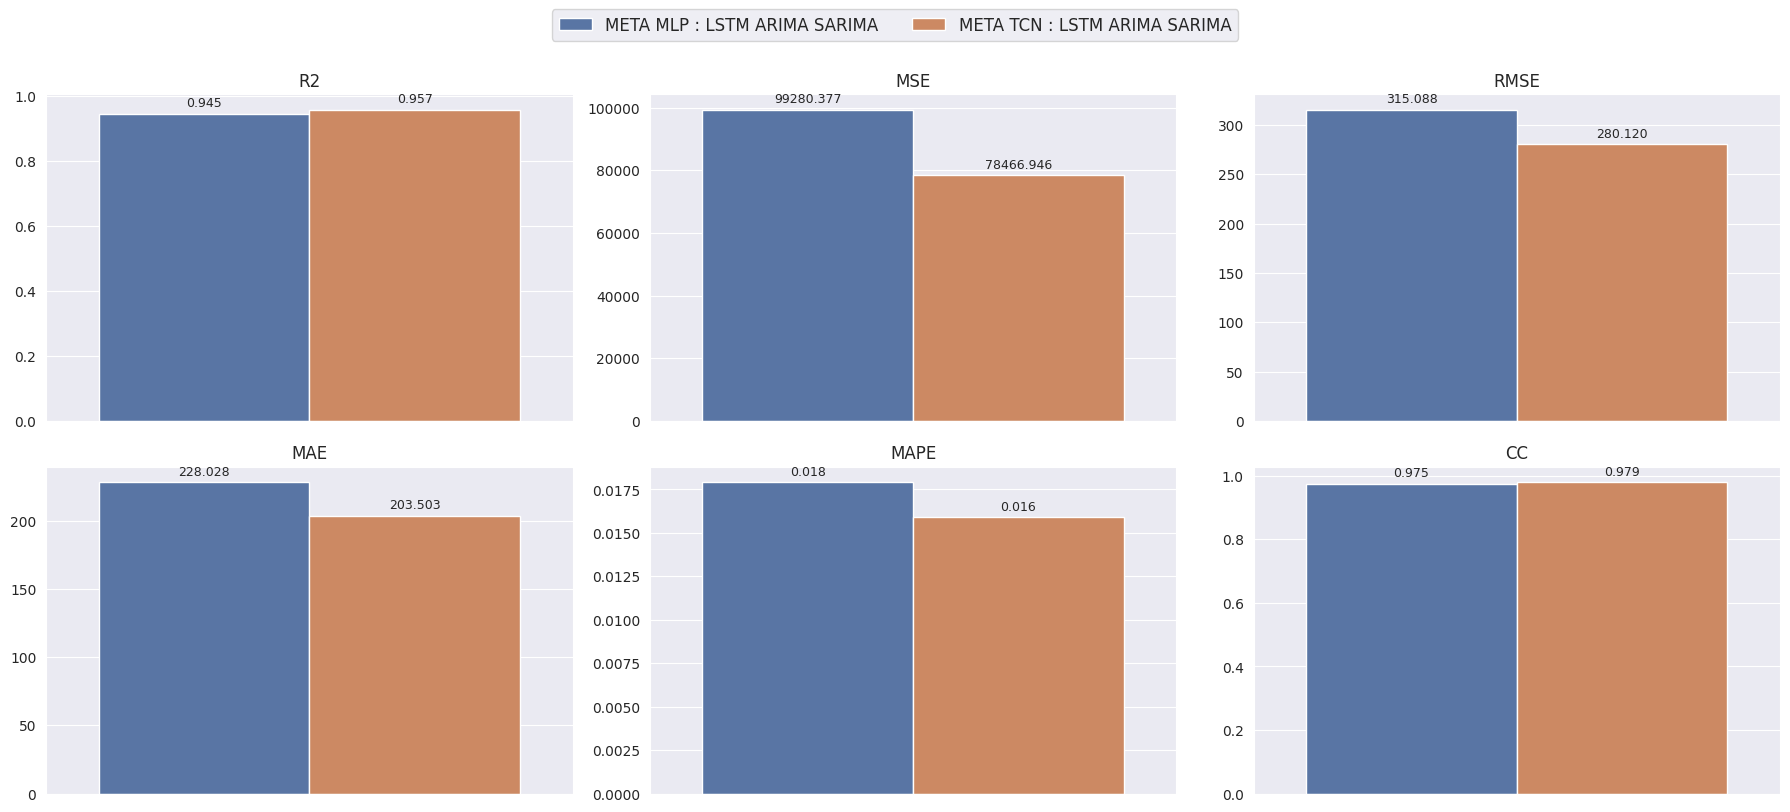

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# =========================
# STYLE
# =========================
sns.set_style("darkgrid")

# =========================
# TAMBAHKAN LABEL MODEL
# =========================
df1 = df_result_lstm_arima_tanpa_fold.copy()
df2 = df_result_lstm_arima_tanpa_fold_tcn.copy()

df1["Model_Type"] = "META MLP : LSTM ARIMA SARIMA"
df2["Model_Type"] = "META TCN : LSTM ARIMA SARIMA"

df_all = pd.concat([df1, df2], ignore_index=True)

# Dummy x supaya bar dempet di tengah
df_all["Dummy"] = " "

# =========================
# METRIK
# =========================
metrics = ["r2", "mse", "rmse", "mae", "mape", "cc"]

# =========================
# SUBPLOT SETTING
# =========================
cols = 3
rows = int(np.ceil(len(metrics) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 8))
axes = axes.flatten()

colors = ["#4C72B0", "#DD8452"]

# =========================
# LOOP PER METRIK
# =========================
for i, metric in enumerate(metrics):
    ax = axes[i]

    sns.barplot(
        data=df_all,
        x="Dummy",
        y=metric,
        hue="Model_Type",
        palette=colors,
        dodge=True,
        ax=ax
    )

    ax.set_title(metric.upper(), fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])

    # ❌ HAPUS LEGEND DI SUBPLOT
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # =========================
    # ANGKA DI ATAS BAR
    # =========================
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

# =========================
# HAPUS AXIS SISA
# =========================
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# =========================
# LEGEND GLOBAL ATAS TENGAH
# =========================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=12,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('comparison_meta_learning-lstm-arima-sarima.jpg', dpi=800)
plt.show()


## 1.3.2 COEF vs NO COEF - MLP : LSTM ARIMA SARIMA

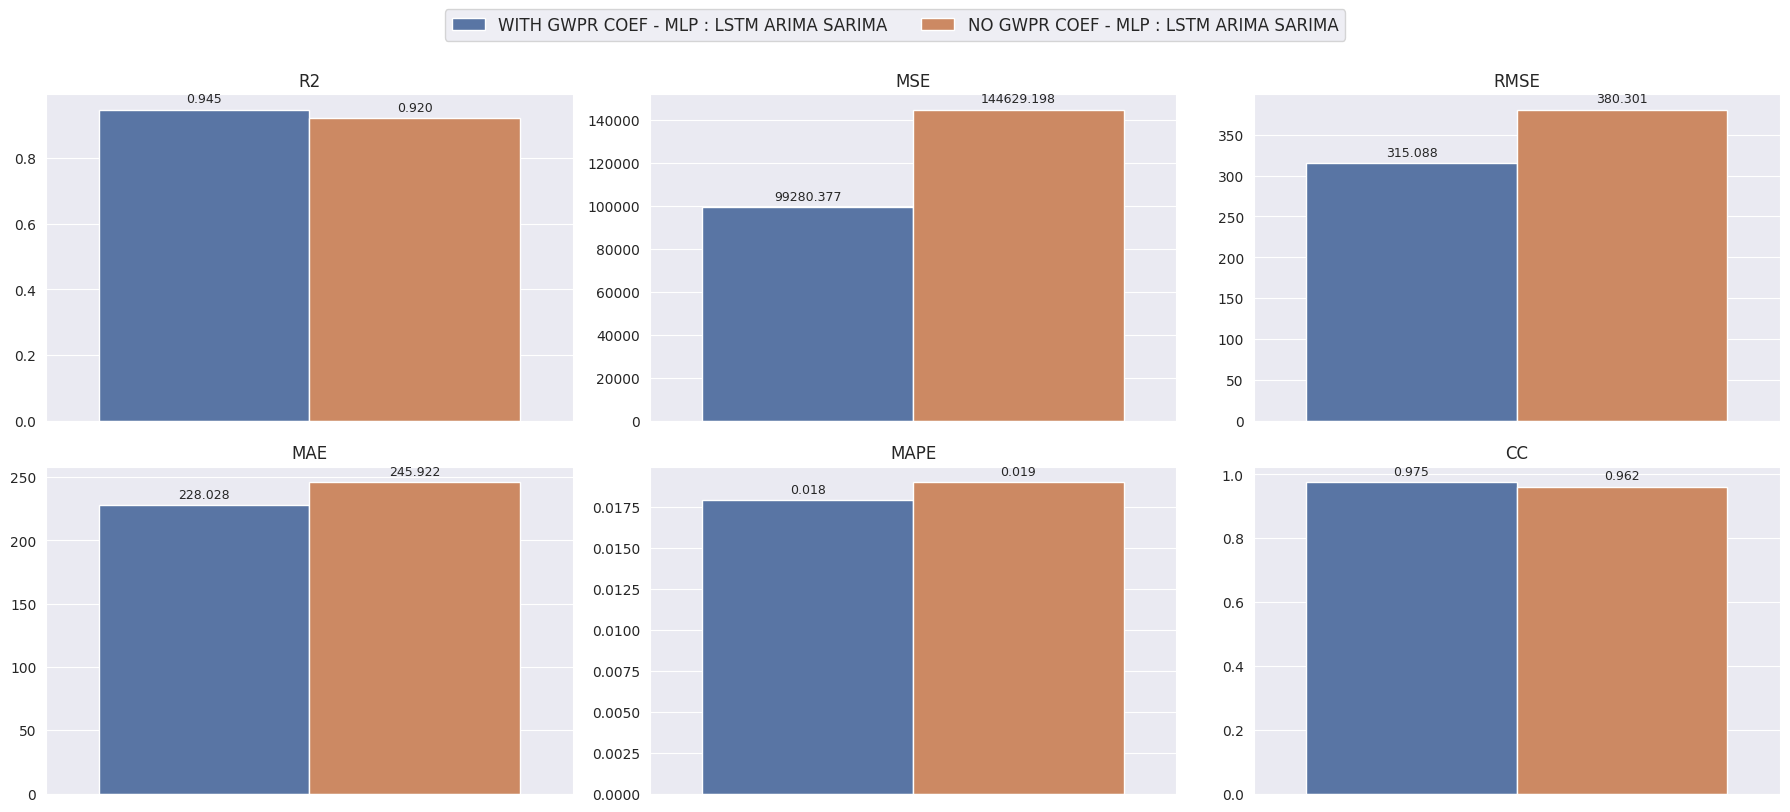

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# =========================
# STYLE
# =========================
sns.set_style("darkgrid")

# =========================
# TAMBAHKAN LABEL MODEL
# =========================
df1 = df_result_lstm_arima_tanpa_fold.copy()
df2 = df_result_lstm_arima_tanpa_fold_no_coef.copy()

df1["Model_Type"] = "WITH GWPR COEF - MLP : LSTM ARIMA SARIMA"
df2["Model_Type"] = "NO GWPR COEF - MLP : LSTM ARIMA SARIMA"

df_all = pd.concat([df1, df2], ignore_index=True)

# Dummy x supaya bar dempet di tengah
df_all["Dummy"] = " "

# =========================
# METRIK
# =========================
metrics = ["r2", "mse", "rmse", "mae", "mape", "cc"]

# =========================
# SUBPLOT SETTING
# =========================
cols = 3
rows = int(np.ceil(len(metrics) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 8))
axes = axes.flatten()

colors = ["#4C72B0", "#DD8452"]

# =========================
# LOOP PER METRIK
# =========================
for i, metric in enumerate(metrics):
    ax = axes[i]

    sns.barplot(
        data=df_all,
        x="Dummy",
        y=metric,
        hue="Model_Type",
        palette=colors,
        dodge=True,
        ax=ax
    )

    ax.set_title(metric.upper(), fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])

    # ❌ HAPUS LEGEND DI SUBPLOT
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # =========================
    # ANGKA DI ATAS BAR
    # =========================
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

# =========================
# HAPUS AXIS SISA
# =========================
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# =========================
# LEGEND GLOBAL ATAS TENGAH
# =========================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=12,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('comparison_coef_vs_no_coef-lstm-arima-sarima.jpg', dpi=800)
plt.show()


## 1.3.3 TIME INFERENCE PLOT

In [45]:
df_time_summary

,TIME_ARIMA,TIME_SARIMA,TIME_LSTM,TIME_LSTM_ARIMA,TIME_LSTM_SARIMA,TIME_LSTM_ARIMA_SARIMA,TIME_TOTAL
0,0.0122,0.013175,0.116642,0.154241,0.155035,0.147475,0.598768


In [46]:
df_time_summary_tcn

,TIME_ARIMA,TIME_SARIMA,TIME_LSTM,TIME_LSTM_ARIMA,TIME_LSTM_SARIMA,TIME_LSTM_ARIMA_SARIMA,TIME_TOTAL
0,0.011342,0.012758,0.113897,0.610171,0.601617,0.575845,1.92563


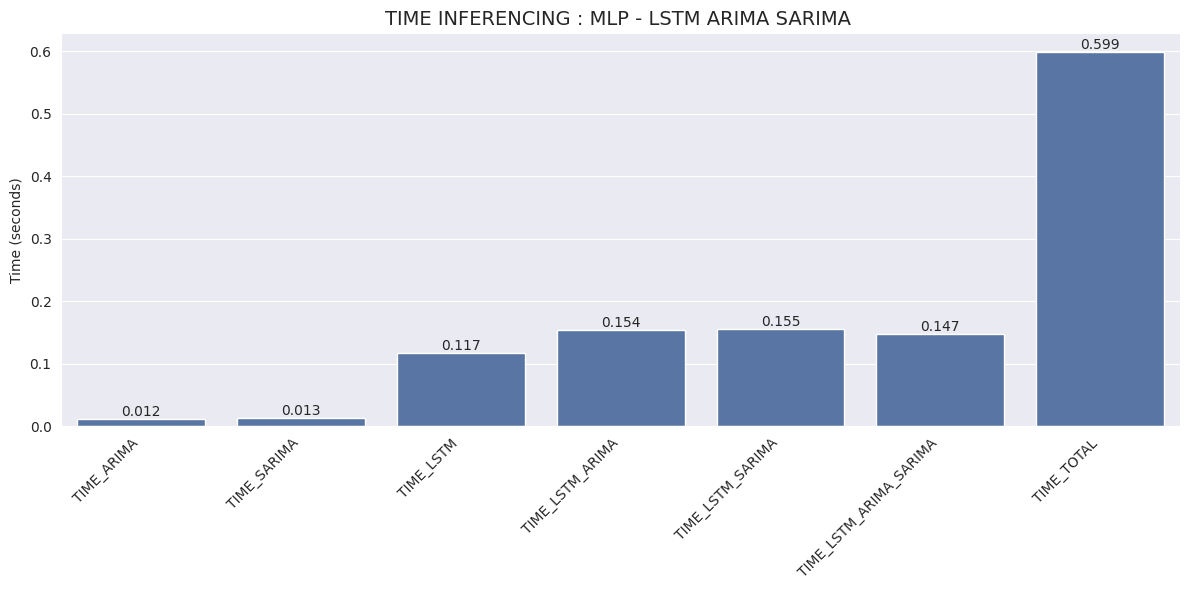

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# STYLE
# =========================
sns.set_style("darkgrid")

# =========================
# AMBIL DATA
# =========================
time_values = df_time_summary.iloc[0]

# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=time_values.index,
    y=time_values.values,
    color="#4C72B0"   # 🔵 SATU WARNA BIRU
)

plt.title("TIME INFERENCING : MLP - LSTM ARIMA SARIMA ", fontsize=14)
plt.ylabel("Time (seconds)")
plt.xlabel("")

# =========================
# ANGKA DI ATAS BAR
# =========================
for i, v in enumerate(time_values.values):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

# =========================
# ROTATE LABEL
# =========================
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig('time_inference_MLP-LSTM-ARIMA-SARIMA.jpg', dpi=800)
plt.show()


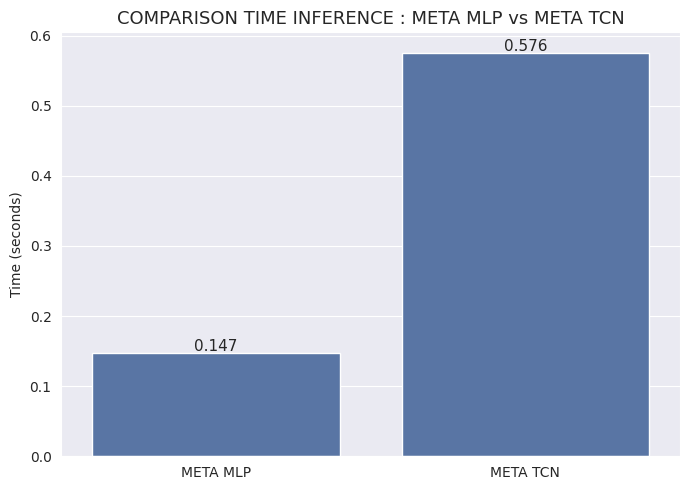

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================
# STYLE
# =========================
sns.set_style("darkgrid")

# =========================
# AMBIL NILAI
# =========================
time_mlp = df_time_summary["TIME_LSTM_ARIMA_SARIMA"].iloc[0]
time_tcn = df_time_summary_tcn["TIME_LSTM_ARIMA_SARIMA"].iloc[0]

# =========================
# BENTUK DATAFRAME BARU
# =========================
df_compare = pd.DataFrame({
    "Model": ["META MLP", "META TCN"],
    "Time": [time_mlp, time_tcn]
})

# =========================
# PLOT
# =========================
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=df_compare,
    x="Model",
    y="Time",
    color="#4C72B0"  # 🔵 satu warna biru
)

plt.title("COMPARISON TIME INFERENCE : META MLP vs META TCN", fontsize=13)
plt.ylabel("Time (seconds)")
plt.xlabel("")

# =========================
# ANGKA DI ATAS BAR
# =========================
for i, v in enumerate(df_compare["Time"]):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig('COMPARISON TIME INFERENCE : META MLP vs META TCN.jpg', dpi =800)
plt.show()


## 1.3.4 LINE PLOT : PRED VS ACTUAL (MLP VS TCN)

In [60]:
df_meta3_tanpa_fold
df_meta3_tanpa_fold_tcn

,actual,prediction
0,12025.0,11646.095703
1,11250.0,11125.720703
2,13000.0,12654.825195
3,14500.0,14079.036133
4,14500.0,14039.717773
...,...,...
619,13239.0,13071.088867
620,12424.0,12471.033203
621,12500.0,12529.534180
622,12500.0,12531.197266


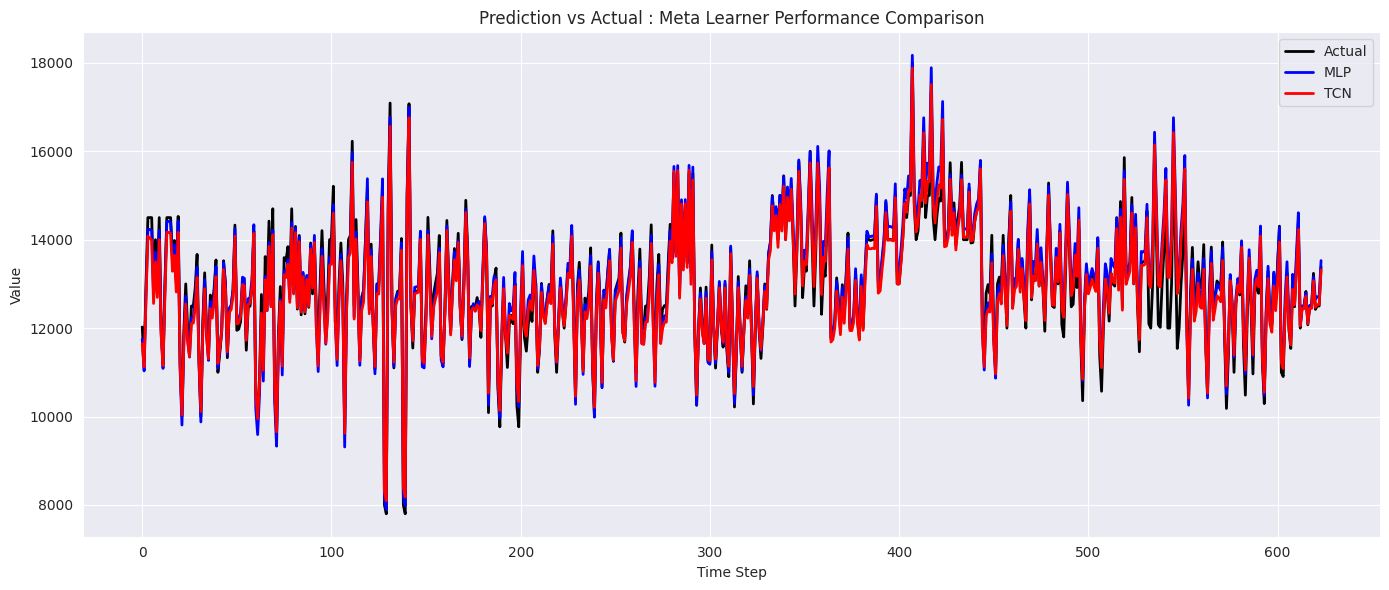

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

plt.figure(figsize=(14,6))

# Actual (dari df_meta3_tanpa_fold)
plt.plot(df_meta3_tanpa_fold['actual'].values,
         label='Actual',
         color='black',
         linewidth=2)

# MLP prediction (df_meta3_tanpa_fold)
plt.plot(df_meta3_tanpa_fold['prediction'].values,
         label='MLP',
         color='blue',
         linewidth=2)

# TCN prediction (df_meta3_tanpa_fold_tcn)
plt.plot(df_meta3_tanpa_fold_tcn['prediction'].values,
         label='TCN',
         color='red',
         linewidth=2)

plt.title("Prediction vs Actual : Meta Learner Performance Comparison")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig('Prediction vs Actual : Meta Learner Performance Comparison.jpg', dpi=800)
plt.show()


## 1.3.5 LINE PLOT : PRED VS ACTUAL - MLP LSTM ARIMA SARIMA (WITH COEF VS NO COEF) - GWPR

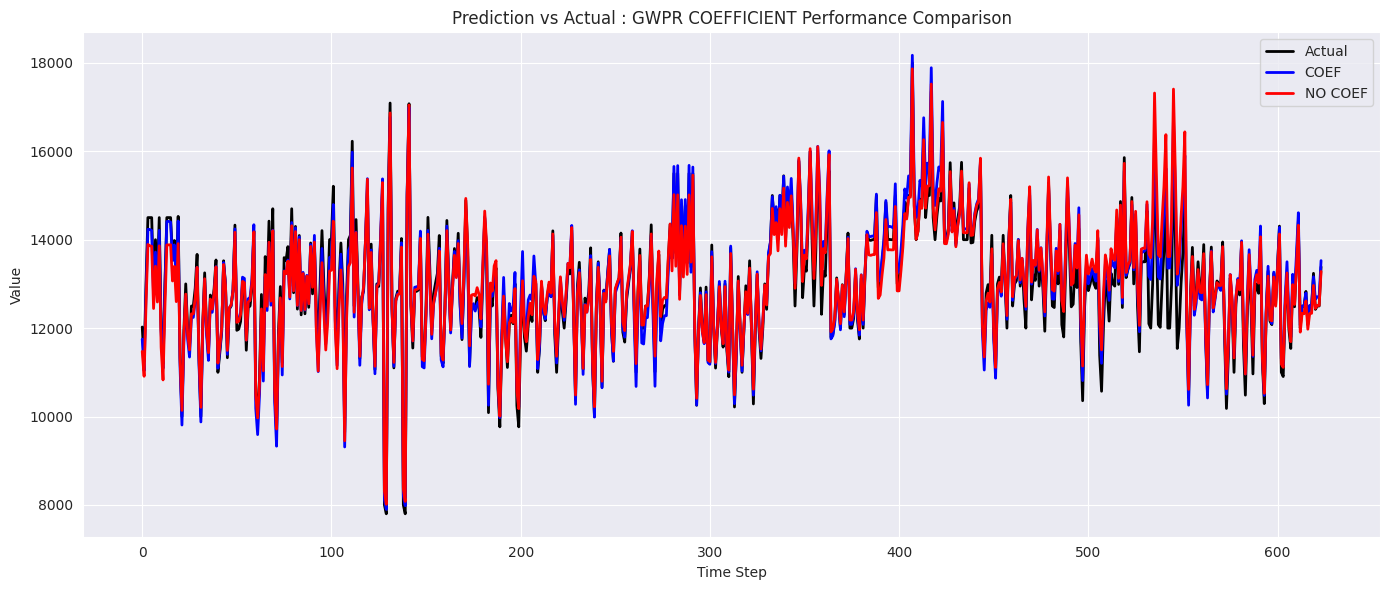

In [66]:
plt.figure(figsize=(14,6))

# Actual
plt.plot(df_meta3_tanpa_fold['actual'].values,
         label='Actual',
         color='black',
         linewidth=2)

# COEF (df_meta3_tanpa_fold)
plt.plot(df_meta3_tanpa_fold['prediction'].values,
         label='COEF',
         color='blue',
         linewidth=2)

# NO COEF (df_meta3_tanpa_fold_no_coef)
plt.plot(df_meta3_tanpa_fold_no_coef['prediction'].values,
         label='NO COEF',
         color='red',
         linewidth=2)

plt.title("Prediction vs Actual : GWPR COEFFICIENT Performance Comparison")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig('Prediction vs Actual : GWPR COEFFICIENT Performance Comparison.jpg', dpi = 800)
plt.show()


# SHAP VALUES ONLY MLP : LSTM ARIMA SARIMA

In [67]:
fitur_cols = kolom_fitur_coef
target_cols = kolom_target

In [58]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

######################################### PARAMETERS #########################################
lookback_lstm = 1

order = (2, 1, 2)
seasonal_order = (1,0,1,12)

epoch = 100
batchsize = 32

epochmlp = 50
batchsizemlp = 32

result = []
result_sarima = []
result_arima = []
result_lstm = []

pred_meta1 = []
pred_meta2 = []
pred_meta3 = []

###########################################################################################################################

X = data[fitur_cols]
y = data[target_cols]

# ==============================
# 1. BUAT TIME KEY
# ==============================
time_key = pd.Series(
    data.index.get_level_values('Year') * 100 +
    data.index.get_level_values('Month'),
    index=data.index
)

meta_full_model = None
Xm_train_full = None
Xm_test_full = None


# ==============================
# 2. TRAIN / VAL / TEST SPLIT 80:10:10 per Province
# ==============================
train_index = []
val_index   = []
test_index  = []

provinces = X.index.get_level_values('Province').unique()

for prov in provinces:
    idx_prov = X.index[X.index.get_level_values('Province') == prov]
    idx_sorted = idx_prov.sort_values()
    
    n = len(idx_sorted)
    n_train = int(n * 0.8)
    n_val   = int(n * 0.1)
    n_test  = n - n_train - n_val
    
    if n_train > 0:
        train_index.extend(idx_sorted[:n_train])
    if n_val > 0:
        val_index.extend(idx_sorted[n_train:n_train+n_val])
    if n_test > 0:
        test_index.extend(idx_sorted[n_train+n_val:])

train_mask = X.index.isin(train_index)
val_mask   = X.index.isin(val_index)
test_mask  = X.index.isin(test_index)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

y_train = np.array(y_train).reshape(-1,1)
y_val   = np.array(y_val).reshape(-1,1)
y_test  = np.array(y_test).reshape(-1,1)

# ==============================
# 3. SCALING
# ==============================
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

X_val_scaled = scaler_x.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_x.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=fitur_cols)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=fitur_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=fitur_cols)

# ==============================
# 4. SARIMA — TRAINING & EVALUASI
# ==============================

y_train_sarima = y_train_scaled.ravel()
y_val_sarima   = y_val_scaled.ravel()
y_test_sarima  = y_test_scaled.ravel()

model_sarima = sm.tsa.SARIMAX(
    endog=y_train_sarima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = model_sarima.fit(disp=False)

sarima_pred_train = sarima_fit.predict(start=0, end=len(y_train_sarima)-1).reshape(-1,1)
sarima_pred_val   = sarima_fit.get_forecast(steps=len(y_val_sarima)).predicted_mean.reshape(-1,1)

start_time = time.time()
sarima_pred_test  = sarima_fit.get_forecast(steps=len(y_test_sarima)).predicted_mean.reshape(-1,1)
time_sarima = time.time() - start_time

sarima_pred_train = sarima_pred_train[lookback_lstm-1:]
sarima_pred_val   = sarima_pred_val[lookback_lstm-1:]
sarima_pred_test  = sarima_pred_test[lookback_lstm-1:]

y_train_eff = y_train_sarima[lookback_lstm-1:].reshape(-1,1)
y_val_eff   = y_val_sarima[lookback_lstm-1:].reshape(-1,1)
y_test_eff  = y_test_sarima[lookback_lstm-1:].reshape(-1,1)

sarima_pred_test_orig  = scaler_y.inverse_transform(sarima_pred_test)


# EVALUASI SARIMA
r2_sarima, mse_sarima, rmse_sarima, mae_sarima, mape_sarima, cc_sarima = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_eff), sarima_pred_test_orig
)

print("=== EVALUASI SARIMA ===")
print("R2    :", r2_sarima)
print("MSE   :", mse_sarima)
print("RMSE  :", rmse_sarima)
print("MAE   :", mae_sarima)
print("MAPE  :", mape_sarima)
print("CC    :", cc_sarima)
print("-----------------------")

result_sarima.append({
    'R2_sarima': r2_sarima, 'MSE_sarima': mse_sarima,
    'RMSE_sarima': rmse_sarima, 'MAE_sarima': mae_sarima,
    'MAPE_sarima': mape_sarima, 'CC_sarima': cc_sarima
})

# ==============================
# 5. ARIMA — TRAINING & EVALUASI
# ==============================

y_train_arima = y_train_scaled.ravel()
y_val_arima   = y_val_scaled.ravel()
y_test_arima  = y_test_scaled.ravel()

model_arima = sm.tsa.ARIMA(
    endog=y_train_arima,
    order=order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
arima_fit = model_arima.fit()

arima_pred_train  = arima_fit.get_forecast(steps=len(y_train_arima)).predicted_mean.reshape(-1,1)
arima_pred_val  = arima_fit.get_forecast(steps=len(y_val_arima)).predicted_mean.reshape(-1,1)

start_time = time.time()
arima_pred_test  = arima_fit.get_forecast(steps=len(y_test_arima)).predicted_mean.reshape(-1,1)
time_arima = time.time() - start_time

arima_pred_train = arima_pred_train[lookback_lstm-1:]
arima_pred_val   = arima_pred_val[lookback_lstm-1:]
arima_pred_test  = arima_pred_test[lookback_lstm-1:]

y_train_eff = y_train_arima[lookback_lstm-1:].reshape(-1,1)
y_val_eff   = y_val_arima[lookback_lstm-1:].reshape(-1,1)
y_test_eff  = y_test_arima[lookback_lstm-1:].reshape(-1,1)

arima_pred_test_orig  = scaler_y.inverse_transform(arima_pred_test)


# EVALUASI ARIMA
r2_arima, mse_arima, rmse_arima, mae_arima, mape_arima, cc_arima = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_eff), arima_pred_test_orig
)

print("=== EVALUASI ARIMA ===")
print("R2    :", r2_arima)
print("MSE   :", mse_arima)
print("RMSE  :", rmse_arima)
print("MAE   :", mae_arima)
print("MAPE  :", mape_arima)
print("CC    :", cc_arima)
print("-----------------------")

result_arima.append({
    'R2_arima': r2_arima, 'MSE_arima': mse_arima,
    'RMSE_arima': rmse_arima, 'MAE_arima': mae_arima,
    'MAPE_arima': mape_arima, 'CC_arima': cc_arima
})

# ==============================
# 6. LSTM — TRAINING & EVALUASI
# ==============================

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, lookback_lstm)
X_val_seq, y_val_seq     = make_sequences(X_val_scaled, y_val_scaled, lookback_lstm)
X_test_seq, y_test_seq   = make_sequences(X_test_scaled, y_test_scaled, lookback_lstm)

model_lstm = lstm(X_train_seq, y_train_seq, X_val_seq, y_val_seq, epoch=epoch, batchsize=batchsize, callbacks=callbacks)
y_pred_train_lstm  = model_lstm.predict(X_train_seq)
y_pred_val_lstm  = model_lstm.predict(X_val_seq)
start_time = time.time()
y_pred_test_lstm  = model_lstm.predict(X_test_seq)
y_pred_test_lstm_orig  = scaler_y.inverse_transform(y_pred_test_lstm)
time_lstm = time.time() - start_time

# EVALUASI LSTM
r2_lstm, mse_lstm, rmse_lstm, mae_lstm, mape_lstm, cc_lstm = evaluate_forecast_ts(
    scaler_y.inverse_transform(y_test_seq), y_pred_test_lstm_orig
)

print("=== EVALUASI LSTM ===")
print("R2    :", r2_lstm)
print("MSE   :", mse_lstm)
print("RMSE  :", rmse_lstm)
print("MAE   :", mae_lstm)
print("MAPE  :", mape_lstm)
print("CC    :", cc_lstm)
print("-----------------------")

result_lstm.append({
    'R2_lstm': r2_lstm, 'MSE_lstm': mse_lstm,
    'RMSE_lstm': rmse_lstm, 'MAE_lstm': mae_lstm,
    'MAPE_lstm': mape_lstm, 'CC_lstm': cc_lstm
})

print(y_pred_train_lstm.shape)
print(arima_pred_train.shape)
# # ==============================
# # 7. META LEARNING - MLP
# # ==============================
X_meta_train_1 = np.hstack((arima_pred_train, y_pred_train_lstm))
X_meta_val_1   = np.hstack((arima_pred_val,   y_pred_val_lstm))
X_meta_test_1  = np.hstack((arima_pred_test,  y_pred_test_lstm))

X_meta_train_2 = np.hstack((sarima_pred_train, y_pred_train_lstm))
X_meta_val_2   = np.hstack((sarima_pred_val,   y_pred_val_lstm))
X_meta_test_2  = np.hstack((sarima_pred_test,  y_pred_test_lstm))

X_meta_train_3 = np.hstack((arima_pred_train, sarima_pred_train, y_pred_train_lstm))
X_meta_val_3   = np.hstack((arima_pred_val,   sarima_pred_val,   y_pred_val_lstm))
X_meta_test_3  = np.hstack((arima_pred_test,  sarima_pred_test,  y_pred_test_lstm))

y_meta_train = y_train_eff
y_meta_val   = y_val_eff
y_meta_test  = y_test_eff

# # ==============================
# # 7. META LEARNING - MLP (training & testing)
# # ==============================
meta_variants = {
    "LSTM_ARIMA":  (X_meta_train_1, X_meta_val_1, X_meta_test_1),
    "LSTM_SARIMA": (X_meta_train_2, X_meta_val_2, X_meta_test_2),
    "LSTM_ARIMA_SARIMA": (X_meta_train_3, X_meta_val_3, X_meta_test_3)
}

time_meta = {}
total_meta_time = 0

for name, (Xm_train, Xm_val, Xm_test) in meta_variants.items():
    
    # TRAIN META MLP
    meta_mlp = mlp(
        Xm_train, y_meta_train,    # training
        Xm_val, y_meta_val,        # validation
        epoch=epochmlp,
        batchsize=batchsizemlp,
        callbacks=callbacks,
        input_dim=Xm_train.shape[1]
    )
    
    # PREDIKSI TEST META & HITUNG TIME
    start_time = time.time()
    y_pred_meta_scaled = meta_mlp.predict(Xm_test)  # masih scaled
    time_taken = time.time() - start_time
    time_meta[name] = time_taken
    total_meta_time += time_taken

    # INVERSE SCALING HANYA SETELAH PREDIKSI
    y_true = scaler_y.inverse_transform(y_meta_test.reshape(-1,1))
    y_pred = scaler_y.inverse_transform(y_pred_meta_scaled.reshape(-1,1))

    # EVALUASI
    r2, mse, rmse, mae, mape, cc = evaluate_forecast_ts(y_true, y_pred)

    print(f"=== EVALUASI META {name} ===")
    print("R2    :", r2)
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("MAE   :", mae)
    print("MAPE  :", mape)
    print("CC    :", cc)
    print("-----------------------")

    # SIMPAN HASIL
    result.append({
        'model': name,
        'R2_meta': r2,
        'MSE_meta': mse,
        'RMSE_meta': rmse,
        'MAE_meta': mae,
        'MAPE_meta': mape,
        'CC_meta': cc
    })

    # =========================
    # SIMPAN PREDIKSI PER META
    # =========================
    
    df_pred_fold = pd.DataFrame({
        'actual': y_true.ravel(),
        'prediction': y_pred.ravel()
    })
    
    if name == "LSTM_ARIMA":
        pred_meta1.append(df_pred_fold)
    
    elif name == "LSTM_SARIMA":
        pred_meta2.append(df_pred_fold)
    
    elif name == "LSTM_ARIMA_SARIMA":
        pred_meta3.append(df_pred_fold)
        meta_full_model = meta_mlp

=== EVALUASI SARIMA ===
R2    : -0.1434753334605674
MSE   : 2074785.4147809409
RMSE  : 1440.4115435461285
MAE   : 1135.2912732161892
MAPE  : 0.09292092896407723
CC    : -0.03702669913469959
-----------------------
=== EVALUASI ARIMA ===
R2    : -0.1429082134833839
MSE   : 2073756.400666985
RMSE  : 1440.0543047631868
MAE   : 1134.9755319028602
MAPE  : 0.09289006751926565
CC    : -0.034766997601552926
-----------------------


2026-02-17 09:09:27.755217: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-02-17 09:10:30.449168: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
=== EVALUASI LSTM ===
R2    : 0.8876614720978273
MSE   : 203833.2899617614
RMSE  : 451.47900279167067
MAE   : 339.62713310046075
MAPE  : 0.02648066168303177
CC    : 0.9521576730598355
-----------------------
(3368, 1)
(3368, 1)
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


2026-02-17 09:10:46.061514: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


=== EVALUASI META LSTM_ARIMA ===
R2    : 0.8784794541108731
MSE   : 220493.65546342425
RMSE  : 469.56751960013617
MAE   : 325.7776990059094
MAPE  : 0.02480542636888434
CC    : 0.9521568979920907
-----------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


2026-02-17 09:11:02.482595: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


=== EVALUASI META LSTM_SARIMA ===
R2    : 0.8758916077940526
MSE   : 225189.18814062193
RMSE  : 474.54102893282254
MAE   : 332.25621228340333
MAPE  : 0.02531265066904978
CC    : 0.9525302284359061
-----------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
=== EVALUASI META LSTM_ARIMA_SARIMA ===
R2    : 0.891579017846404
MSE   : 196725.0764804215
RMSE  : 443.5370068894156
MAE   : 312.02280836838935
MAPE  : 0.023922123078652296
CC    : 0.9534771752267661
-----------------------


2026-02-17 09:11:24.648026: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



===== SHAP ANALYSIS: LSTM_ARIMA_SARIMA =====

Shape train: (3368, 3)
Shape test : (624, 3)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


2026-02-17 09:29:15.877665: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━

2026-02-17 09:29:20.919590: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


...

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━

2026-02-17 09:29:46.187059: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━

2026-02-17 09:29:51.215587: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━

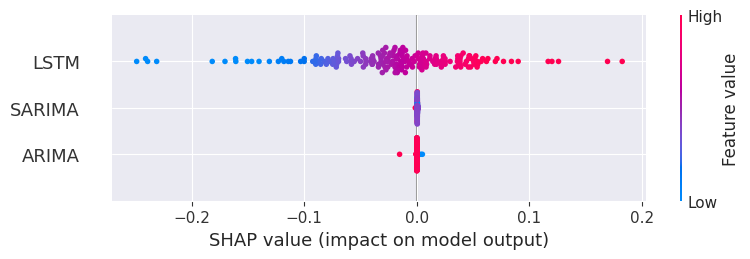


===== KONTRIBUSI MODEL =====
LSTM : 0.050021
ARIMA : 0.000160
SARIMA : 0.000421

Model paling berkontribusi:
LSTM


In [71]:
# =========================================================
# 🔥 SHAP ANALYSIS — LSTM + ARIMA + SARIMA (FINAL FIX)
# =========================================================
import shap
import numpy as np

print("\n===== SHAP ANALYSIS: LSTM_ARIMA_SARIMA =====\n")

# PASTIKAN INI DIPAKAI (bukan dari loop)
Xm_train_full = X_meta_train_3
Xm_test_full  = X_meta_test_3

print("Shape train:", Xm_train_full.shape)
print("Shape test :", Xm_test_full.shape)
# HARUS (n, 3)

# =========================
# BACKGROUND
# =========================
background = Xm_train_full[:100]

# fungsi prediksi harus 1D
f = lambda x: meta_full_model.predict(x).reshape(-1)

explainer = shap.KernelExplainer(f, background)

# =========================
# SHAP VALUES
# =========================
X_sample = Xm_test_full[:200]
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

# =========================================================
# 🔥 REORDER → LSTM, ARIMA, SARIMA
# dari urutan asli [ARIMA, SARIMA, LSTM]
# =========================================================
shap_values = shap_values[:, [2, 0, 1]]
X_sample = X_sample[:, [2, 0, 1]]

feature_names = ["LSTM", "ARIMA", "SARIMA"]

# =========================================================
# 🐝 BEESWARM — 3 MODEL DALAM 1 PLOT
# =========================================================
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    show=False
)

plt.savefig("SHAP-LSTM-ARIMA-SARIMA.jpg",
            dpi=800,
            bbox_inches='tight')
plt.show()

# =========================================================
# 📊 GLOBAL CONTRIBUTION
# =========================================================
mean_importance = np.mean(np.abs(shap_values), axis=0)

print("\n===== KONTRIBUSI MODEL =====")

for name, val in zip(feature_names, mean_importance):
    print(f"{name} : {float(val):.6f}")

print("\nModel paling berkontribusi:")
print(feature_names[np.argmax(mean_importance)])
